this file is suposed to be a more clean and short version of the lapses models 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, average_precision_score
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from lightgbm import LGBMClassifier
import shap
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

from sklearn.isotonic import IsotonicRegression
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibrationDisplay
import optuna
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from optuna import visualization as vis
from sklearn.neural_network import MLPClassifier



C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import the data with nan handeling 

data = pd.read_parquet(r"DATA_2025\lapses_pp_renov_period_2025-01-01_2025-12-31_nan_imputation.parquet")

In [3]:
target_var="is_lapse"

In [4]:
# delete the midterm ( end of the list fo get the midterm col for the midterm model)


cols_to_exclude =  [
 "key_PN",
 "idade_bin",
 "N_hospitais_Privado",
 "N_pessoas_total",
 "N_pessoas_total",
 "RENOVACAO",
 "prem_inicial",
 'POLIZA',
 'NASEGURADO',
 'ASEGURADO',
 'FALTAASEG',
 'FNACI8',
 'POLIZAS_45',
 'FECHA_PREEXISTENCIA',
 'DESCGARA',
 'FEFECTO',
 'PRIANUALAA',
 'TOMADOR',
 'FVTO_AC',
 'FCob',
 'fefecto_poliza',
 'fbajaaseg',
 'INICIO',
 'FIM',
 'EXPOSICAO',
 'min_faltaaseg',
 'min_fecha',
 'max_fbajaaseg',
 'FECHA_novo',
 'fecha',
 'p_exp_year',
 'aux_prem_aa',
 'aux_prem_ac',
 'aux_ren',
 'aux_gar',
 'aux_ren_apol',
 'prem_final',
 'prem_exp',
 'Ren2',
 'ren_apolice2',
 'Ren_final',
 'ren_inicial',
 'premio2',
 'IDADE',
 'data_inicio2',
 'dt_antiga',
 'data_pre_existencia',
 'aux_ren2',
 'dif_meses',
 'tenure',
 'new_ant_pessoa',
 'codpost_tom',
 'codpost_tomador',
 'codine_tomador',
 'cp4',
 'codine_tomador_n',
 'cp7',
 'Crime_rate_2011',
 'Crime_rate_2012',
 'Crime_rate_2013',
 'Crime_rate_2014',
 'Crime_rate_2015',
 'zip_code',
 'Concelho',
 'CODINE',
 'Concentracao',
 'N_Homens',
 'N_Mulheres',
 'N_hospitais_PP',
 'N_hospitais_Publico',
 'Capital_Hosp_Cirurgia_e_Parto',
 'Capital_Parto',
 'Capital_Hosp_Cirurgia',
 'Capital_Prot_n_Oculares',
 'Capital_Prot_Oculares',
 'Capital_Cob_Medica_Int',
 'Capital_Consultas',
 'Capital_Medicamentos',
 'Capital_Estomat_Consult_e_Trat',
 'Bin_Hosp_Cirurgia_e_Parto',
 'Bin_DENTAL',
 'Bin_assist_port',
 'Bin_Cob_Medica_Int',
 'Bin_Consultas',
 'Bin_Medicamentos',
 'Cap_Oncologia',
 'CodigoPostal',
 'Freguesia_Final_Pos_RATF',
 'freg_ratf_github',
 'conc_ratf_github',
 'key_merge_comp',
 'REFSTRO',
 'refstro2',
 'FECHSTRO',
 'SINISTRALIDADE',
 'cst_Ambul',
 'cst_Cesariana',
 'cst_Consulta_Domicilio',
 'cst_Consultas',
 'cst_Consultas_Urg',
 'cst_EAD_ECO',
 'cst_EAD_RM',
 'cst_EAD_TAC',
 'cst_EADs_Analises',
 'cst_EADs_AnatomiaPat',
 'cst_EADs_Endo',
 'cst_EADs_MedNuclear',
 'cst_EADs_Outros',
 'cst_EADs_RX',
 'cst_ERRO',
 'cst_Estomat',
 'cst_Estomat_Consult_e_Trat',
 'cst_Estomat_Prot',
 'cst_Fisio',
 'cst_Hosp_Cirurgia',
 'cst_Hosp_Cirurgia_e_Parto',
 'cst_Lesoes_Benig_Pele',
 'cst_Lesoes_Malig_Pele',
 'cst_Onc_Pacote_Total',
 'cst_Medicamentos',
 'cst_NOT_HOSP',
 'cst_Parto_Norm_e_IIG',
 'cst_Prot_Aros',
 'cst_Prot_Lentes',
 'cst_Prot_Lentes_contacto',
 'cst_Prot_Oculares',
 'cst_Prot_n_Oculares',
 'cst_Quimio_Radio',
 'cst_Subs_Desloc',
 'cst_Subs_Hosp',
 'cst_Tratamentos',
 'cont_Ambul',
 'cont_Cesariana',
 'cont_Consulta_Domicilio',
 'cont_Consultas',
 'cont_Consultas_Urg',
 'cont_EAD_ECO',
 'cont_EAD_RM',
 'cont_EAD_TAC',
 'cont_EADs_Analises',
 'cont_EADs_AnatomiaPat',
 'cont_EADs_Endo',
 'cont_EADs_MedNuclear',
 'cont_EADs_Outros',
 'cont_EADs_RX',
 'cont_ERRO',
 'cont_Estomat',
 'cont_Estomat_Consult_e_Trat',
 'cont_Estomat_Prot',
 'cont_Fisio',
 'cont_Hosp_Cirurgia',
 'cont_Hosp_Cirurgia_e_Parto',
 'cont_Lesoes_Benig_Pele',
 'cont_Lesoes_Malig_Pele',
 'cont_Medicamentos',
 'cont_NOT_HOSP',
 'cont_Parto_Norm_e_IIG',
 'cont_Prot_Aros',
 'cont_Prot_Lentes',
 'cont_Prot_Lentes_contacto',
 'cont_Prot_Oculares',
 'cont_Prot_n_Oculares',
 'cont_Quimio_Radio',
 'cont_Subs_Desloc',
 'cont_Subs_Hosp',
 'cont_Tratamentos',
 'n_claims_dia',
 'nclaim_total',
 'dt_start',
 'dt_end',
 'n_claims_dia2',
 'EXPOSICAO_v2',
 'exp_Hosp_Cirurgia_e_Parto',
 'exp_DENTAL',
 'exp_assist_port',
 'exp_Cob_Medica_Int',
 'exp_Consultas',
 'exp_Medicamentos',
 'new_concentracao',
 'excess_Hosp_Cirurgia',
 'cst_Hosp_Cirurgia_v2',
 'cont_LL_Hosp',
 'cst_Estomat_Prot_total',
 'cst_Estomat_Prot_partial',
 'cont_total_est_prot',
 'cont_partial_est_prot',
 'Nr_Line',
 'garantia_label',
 'N_hospitais_PP2',
 'N_hospitais_Privado2',
 'N_hospitais_total2',
 'N_Homens2',
 'N_Mulheres2',
 'Prop_homens',
 'Prop_mulheres',
 'POLIZASNP',
 'key',
 'marca_inicio_new',
 'marca_fim_new',
 'new_nif_tomador',
 'ICART_DIA',
 'APLICA',
 'canceled',
 'is_midterm',
 "N_Prestadores",
 "final_premium",
 "diff_proposed_inc_max_inc", "diff_proposed_inc_max_inc_POLIZA",
 "TOT_N_PAYMENTS", "TOT_N_PAYMENTS_POLIZA","avg_payment_per_sinister_poliza",
 'POP_NclF_nfilhos00_0_filhosEnt', 'POP_ativa_ecivil02_casado', 'POP_index_trafg_dens_temp_motjov', 'POP_emp_CAE10_actv_info_comunic', 'POP_GSE25_outras_pess_atv_NE', 'N_Domicilios', 'POP_densidade_populacao', 'POP_indice_envelhecimento', 'POP_index_trafg_dens_auto', 'POP_GSE12_diretor_quadros_DEMGE', 'households', 'POP_GSE01_emprs_prof_intelect_CT', 'POP_ativa_ecivil01_solteiro', 'POP_ES_completo', 'POP_idade15_residente_total_abs', 'N_Clientes', 'POP_NclF_nfilhos05_tot_absoluto', 'POP_residente_idade_media', 'POP_indice_dependencia_idosos', 'POP_GSE23_pequenos_patroes_PIC', 'POP_idade14_75_mais_anos', 'POP_ix_trafg_dens_temp_saudavel', 'N_hospitais_total', 'POP_GSE18_prof_intelc_cientf', 'POP_meio_transp_total_abs', 'POP_ativa_ecivil03_viuvo', 'POP_index_trafg_dens_motjov', 'Avg_Number_Floors', 'POP_emp_CAE24_Total_absoluto', 'POP_NclF_nfilhos02_2_filhosEnt', 'POP_index_trafg_dens_saudavel', 'POP_idade04_25_29anos',"IMC","total_premio_ps_2022_onwards","new_estatura","N_pessoas_total2"
]

In [5]:
data= data.drop(columns=cols_to_exclude)

In [6]:
# eleminate nan if there are any left
data = data.dropna()

In [7]:
# creating an identifier of the max_increwase
data["is_max_inc"] = (data["proposed_prem_inc"] >= data["max_increase"]).astype(int)

data["is_max_inc_POLIZA"] = (data["proposed_prem_inc_POLIZA"] >= data["max_increase_POLIZA"]).astype(int)


In [8]:
#lets count the number of unique instances per col and sort ascending
unique_counts= data.nunique().sort_values(ascending= True)


In [9]:
cat_cols = [col for col in data.columns if data[col].nunique() <= data['Distrito'].nunique() and col != target_var]
num_cols = [col for col in data.columns if col not in cat_cols and col != target_var]

In [10]:
X= data[cat_cols + num_cols]
y =data[target_var]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)



X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)




# Get feature names for categorical columns from the OneHotEncoder
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)

# Combine with numerical column names
all_feature_names = list(cat_feature_names) + num_cols

# Convert the encoded arrays to DataFrames
X_train_enc_df = pd.DataFrame(X_train_enc, columns=all_feature_names, index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=all_feature_names, index=X_test.index)

## Functions for modeling and class defenitions

In [11]:
class CalibratedBundle:
    def __init__(self, model, isotonic):
        self.model = model   # stores the base LightGBM (or any model)
        self.isotonic = isotonic  # stores the fitted isotonic regression mapping

    def predict_proba(self, X):
        raw = self.model.predict_proba(X)[:, 1]   # step 1: get raw scores from base model
        cal = self.isotonic.predict(raw)          # step 2: apply isotonic mapping
        probs = np.clip(cal, 0, 1)                # step 3: safety clip to [0,1]
        return np.column_stack([1 - probs, probs])   # return [[prob_0, prob_1], ...]

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)  # threshold at 0.5

In [12]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='neg_brier_score', n_splits=5):
    '''
    This function optimizes the hyperparameters for a classifier by searching over a specified hyperparameter grid. 
    It uses GridSearchCV and cross-validation (StratifiedKFold) to evaluate different combinations of hyperparameters. 
    The combination with the lowest Brier score is selected as the default scoring metric. 
    The function returns the classifier with the optimal hyperparameters.
    '''
    
    # Create the cross-validation object using StratifiedKFold to ensure the class distribution is the same across all the folds
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Create the GridSearchCV object
    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)

    # Fit the GridSearchCV object to the training data
    clf_grid.fit(X_train, y_train)

    # Get the best hyperparameters
    best_hyperparameters = clf_grid.best_params_
    
    # Return best_estimator_ attribute which gives us the best model that has been fitted to the training data
    return clf_grid.best_estimator_, best_hyperparameters

In [13]:
def brier_decomposition(y_true, y_proba, n_bins=10):
    y_true = np.array(y_true)
    bins = np.linspace(0, 1, n_bins + 1)
    n = len(y_true)
    o_bar = y_true.mean()
    REL = RES = 0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_proba >= bins[i]) & (y_proba < bins[i+1])
        else:
            mask = (y_proba >= bins[i]) & (y_proba <= bins[i+1])  # closed last bin
        if mask.sum() == 0:
            continue
        n_b   = mask.sum()
        f_bar = y_proba[mask].mean()
        o_b   = y_true[mask].mean()
        REL += (n_b / n) * (f_bar - o_b) ** 2
        RES += (n_b / n) * (o_b - o_bar) ** 2
    UNC = o_bar * (1 - o_bar)
    BS  = REL - RES + UNC
    return {'Brier Score': BS, 'REL (calibration)': REL,
            'RES (resolution)': RES, 'UNC (uncertainty)': UNC}

In [14]:
def compute_ece(y_true, y_proba, n_bins=10):
    y_true = np.array(y_true)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_proba >= bins[i]) & (y_proba < bins[i+1])
        else:
            mask = (y_proba >= bins[i]) & (y_proba <= bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(y_true)) * abs(y_proba[mask].mean() - y_true[mask].mean())
    return ece

In [15]:
def compute_mce(y_true, y_proba, n_bins=10):
    y_true = np.array(y_true)
    bins = np.linspace(0, 1, n_bins + 1)
    gaps = []
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_proba >= bins[i]) & (y_proba < bins[i+1])
        else:
            mask = (y_proba >= bins[i]) & (y_proba <= bins[i+1])
        if mask.sum() == 0:
            continue
        gaps.append(abs(y_proba[mask].mean() - y_true[mask].mean()))
    return max(gaps)

In [16]:
def metrics_calculator(clf, X_test, y_test, model_name, n_bins=10):
    '''
    This function calculates all desired performance metrics for a given model on test data.
    Includes discrimination metrics, Brier score decomposition, ECE and MCE.
    Discrimination metrics are formatted as percentages; calibration metrics as raw values.
    '''
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    y_test  = np.array(y_test).astype(float)  # ← add this

    brier = brier_decomposition(y_test, y_proba, n_bins=n_bins)
    ece   = compute_ece(y_test, y_proba, n_bins=n_bins)
    mce   = compute_mce(y_test, y_proba, n_bins=n_bins)

    result = pd.DataFrame(
        data=[accuracy_score(y_test, y_pred),
              precision_score(y_test, y_pred, pos_label=1),
              recall_score(y_test, y_pred, pos_label=1),
              f1_score(y_test, y_pred, pos_label=1),
              roc_auc_score(y_test, y_proba),
              average_precision_score(y_test, y_proba),
              brier_score_loss(y_test, y_proba),   # ← exact, not brier['Brier Score']
              brier['REL (calibration)'],
              brier['RES (resolution)'],
              brier['UNC (uncertainty)'],
              ece,
              mce],
        index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC',
               'Brier Score', 'REL (calibration)', 'RES (resolution)', 'UNC (uncertainty)',
               'ECE', 'MCE'],
        columns=[model_name]
    )

    pct_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']
    raw_metrics  = ['Brier Score', 'REL (calibration)', 'RES (resolution)', 'UNC (uncertainty)', 'ECE', 'MCE']

    result_display = result.copy().astype(object)
    result_display.loc[pct_metrics] = (result.loc[pct_metrics] * 100).round(2).astype(str) + '%'
    result_display.loc[raw_metrics] = result.loc[raw_metrics].round(4).astype(str)

    return result_display

In [17]:
def model_evaluation(clf, X_train, X_test, y_train, y_test, model_name):

    y_train = np.array(y_train).astype(float)  
    y_test  = np.array(y_test).astype(float)   
    
    
    
    
    sns.set(font_scale=1.2)

    prob_train = clf.predict_proba(X_train)[:, 1]
    prob_test  = clf.predict_proba(X_test)[:, 1]

    def side_by_side(left_title, left_text, right_title, right_text, pad=60):
        """Print two text blocks side by side."""
        left_lines  = (left_title  + "\n" + "-"*55 + "\n" + left_text).splitlines()
        right_lines = (right_title + "\n" + "-"*35 + "\n" + right_text).splitlines()
        max_lines = max(len(left_lines), len(right_lines))
        left_lines  += [""] * (max_lines - len(left_lines))
        right_lines += [""] * (max_lines - len(right_lines))
        for l, r in zip(left_lines, right_lines):
            print(f"{l:<{pad}}{r}")
        print()

    def prob_metrics_str(split_name, y_true, y_prob):
        bs  = brier_score_loss(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        pr  = average_precision_score(y_true, y_prob)
        ece = compute_ece(y_true, y_prob)
        return (
            f"  {split_name} Probability Metrics\n"
            f"  {'Brier Score':<18} {bs:.4f}\n"
            f"  {'ROC-AUC':<18} {auc:.4f}\n"
            f"  {'PR-AUC':<18} {pr:.4f}\n"
            f"  {'ECE':<18} {ece:.4f}\n"
        )

    # --- Training set ---
    y_pred_train = clf.predict(X_train)
    side_by_side(
        "\t Classification report — TRAIN", classification_report(y_train, y_pred_train),
        "\t Probability Metrics — TRAIN",   prob_metrics_str("Train", y_train, prob_train)
    )

    # --- Test set + overfitting gap ---
    y_pred_test = clf.predict(X_test)
    brier_gap = round(brier_score_loss(y_test, prob_test) - brier_score_loss(y_train, prob_train), 4)
    auc_gap   = round(roc_auc_score(y_test, prob_test)    - roc_auc_score(y_train, prob_train), 4)
    gap_str   = (
        f"  Overfitting Check (Test - Train)\n"
        f"  {'Brier gap':<18} {brier_gap:+.4f}  {'⚠️' if abs(brier_gap) > 0.005 else '✅'}\n"
        f"  {'ROC-AUC gap':<18} {auc_gap:+.4f}  {'⚠️' if abs(auc_gap) > 0.05 else '✅'}\n"
    )
    side_by_side(
        "\t Classification report — TEST",  classification_report(y_test, y_pred_test),
        "\t Probability Metrics — TEST",    prob_metrics_str("Test", y_test, prob_test) + gap_str
    )

    # --- Plots (unchanged) ---
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(22, 7), dpi=100,
                                               gridspec_kw={'width_ratios': [2, 2, 2, 1.5]})
    royalblue   = LinearSegmentedColormap.from_list('royalblue', [(0,(1,1,1)),(1,(0.25,0.41,0.88))])
    royalblue_r = royalblue.reversed()

    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, colorbar=False, cmap=royalblue_r, ax=ax1)
    ax1.set_title('Confusion Matrix for Test Data')
    ax1.grid(False)

    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax2)
    ax2.set_title('ROC Curve for Test Data')

    from sklearn.metrics import PrecisionRecallDisplay
    PrecisionRecallDisplay.from_estimator(clf, X_test, y_test, ax=ax3)
    ax3.set_title('Precision-Recall Curve for Test Data')

    result = metrics_calculator(clf, X_test, y_test, model_name)
    table  = ax4.table(cellText=result.values, colLabels=result.columns,
                       rowLabels=result.index, loc='center')
    table.scale(0.7, 1.5)
    table.set_fontsize(10)
    ax4.axis('tight')
    ax4.axis('off')
    for key, cell in table.get_celld().items():
        if key[0] == 0:
            cell.set_color('royalblue')

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [18]:

def plot_metrics_vs_threshold_interactive(model, X, y_true, thresholds=np.arange(0, 1.01, 0.01)):
    """
    Plots accuracy, precision, recall, F1 (left y-axis, 0-1) and true/false positives (right y-axis) vs threshold.
    Interactive plot using Plotly.
    Args:
        model: fitted classifier with predict_proba
        X: features (DataFrame or ndarray)
        y_true: true binary labels (Series or ndarray)
        thresholds: iterable of thresholds (default 0 to 1 step 0.01)
    """
    y_proba = model.predict_proba(X)[:, 1]
    accs, precs, recs, f1s, tps, fps = [], [], [], [], [], []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        accs.append(accuracy_score(y_true, y_pred))
        precs.append(precision_score(y_true, y_pred, zero_division=0))
        recs.append(recall_score(y_true, y_pred, zero_division=0))
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        cm = confusion_matrix(y_true, y_pred)
        tp = cm[1, 1] if cm.shape == (2, 2) else 0
        fp = cm[0, 1] if cm.shape == (2, 2) else 0
        tps.append(tp)
        fps.append(fp)

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    # Performance metrics (left y-axis)
    fig.add_trace(go.Scatter(x=thresholds, y=accs, mode='lines', name='Accuracy', line=dict(color='royalblue')), secondary_y=False)
    fig.add_trace(go.Scatter(x=thresholds, y=precs, mode='lines', name='Precision', line=dict(color='orange')), secondary_y=False)
    fig.add_trace(go.Scatter(x=thresholds, y=recs, mode='lines', name='Recall', line=dict(color='green')), secondary_y=False)
    fig.add_trace(go.Scatter(x=thresholds, y=f1s, mode='lines', name='F1', line=dict(color='red')), secondary_y=False)
    # True/False Positives (right y-axis)
    fig.add_trace(go.Scatter(x=thresholds, y=tps, mode='lines', name='True Positives', line=dict(dash='dot', color='purple')), secondary_y=True)
    fig.add_trace(go.Scatter(x=thresholds, y=fps, mode='lines', name='False Positives', line=dict(dash='dot', color='brown')), secondary_y=True)
    fig.update_layout(
        title='Metrics vs Threshold (Interactive)',
        xaxis_title='Threshold',
        legend=dict(x=0.01, y=0.99, bordercolor='Black', borderwidth=1),
        hovermode='x unified',
        template='plotly_white',
        width=950,
        height=500
    )
    fig.update_yaxes(title_text='Performance Metrics', range=[0, 1], secondary_y=False)
    fig.update_yaxes(title_text='Count (TP/FP)', secondary_y=True)
    fig.show()
    return fig

# Example usage:
# plot_metrics_vs_threshold_interactive(best_lgbm, X_test_enc_df, y_test)

In [19]:
def plot_metrics_vs_threshold_interactive_probs(y_proba, y_true, thresholds=np.arange(0, 1.01, 0.01)):
    """
    Plots accuracy, precision, recall, F1 (left y-axis, 0-1) and true/false positives (right y-axis) vs threshold.
    Interactive plot using Plotly, for precomputed probability arrays.
    Args:
        y_proba: predicted probabilities (array-like)
        y_true: true binary labels (Series or ndarray)
        thresholds: iterable of thresholds (default 0 to 1 step 0.01)
    """
    accs, precs, recs, f1s, tps, fps = [], [], [], [], [], []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        accs.append(accuracy_score(y_true, y_pred))
        precs.append(precision_score(y_true, y_pred, zero_division=0))
        recs.append(recall_score(y_true, y_pred, zero_division=0))
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        cm = confusion_matrix(y_true, y_pred)
        tp = cm[1, 1] if cm.shape == (2, 2) else 0
        fp = cm[0, 1] if cm.shape == (2, 2) else 0
        tps.append(tp)
        fps.append(fp)

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    # Performance metrics (left y-axis)
    fig.add_trace(go.Scatter(x=thresholds, y=accs, mode='lines', name='Accuracy', line=dict(color='royalblue')), secondary_y=False)
    fig.add_trace(go.Scatter(x=thresholds, y=precs, mode='lines', name='Precision', line=dict(color='orange')), secondary_y=False)
    fig.add_trace(go.Scatter(x=thresholds, y=recs, mode='lines', name='Recall', line=dict(color='green')), secondary_y=False)
    fig.add_trace(go.Scatter(x=thresholds, y=f1s, mode='lines', name='F1', line=dict(color='red')), secondary_y=False)
    # True/False Positives (right y-axis)
    fig.add_trace(go.Scatter(x=thresholds, y=tps, mode='lines', name='True Positives', line=dict(dash='dot', color='purple')), secondary_y=True)
    fig.add_trace(go.Scatter(x=thresholds, y=fps, mode='lines', name='False Positives', line=dict(dash='dot', color='brown')), secondary_y=True)
    fig.update_layout(
        title='Metrics vs Threshold (Calibrated Probabilities, Interactive)',
        xaxis_title='Threshold',
        legend=dict(x=0.01, y=0.99, bordercolor='Black', borderwidth=1),
        hovermode='x unified',
        template='plotly_white',
        width=950,
        height=500
    )
    fig.update_yaxes(title_text='Performance Metrics', range=[0, 1], secondary_y=False)
    fig.update_yaxes(title_text='Count (TP/FP)', secondary_y=True)
    fig.show()

In [20]:
def calibration_results(model, X_train, X_test, y_train, y_test, model_name='Model'):
    
    y_train = np.array(y_train).astype(float)  
    y_test  = np.array(y_test).astype(float)   
    # --- 3-way split: 80% retrain model, 20% fit isotonic ---
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

    # Retrain on reduced training set (ensures X_cal is truly held out)
    fitted_model = clone(model)
    fitted_model.fit(X_tr, y_tr)

    # Score calibration set with retrained model
    prob_cal_data = fitted_model.predict_proba(X_cal)[:, 1]

    # Fit isotonic regression on calibration set
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(prob_cal_data, y_cal)

    # Apply to test set
    prob_raw = fitted_model.predict_proba(X_test)[:, 1]
    prob_cal = iso.predict(prob_raw)

    # Brier scores
    brier_raw = brier_score_loss(y_test, prob_raw)
    brier_cal = brier_score_loss(y_test, prob_cal)

    print(f"Brier Score — Uncalibrated: {brier_raw:.4f}")
    print(f"Brier Score — Calibrated:   {brier_cal:.4f}")

    # Brier decomposition
    decomp_raw = brier_decomposition(y_test, prob_raw)
    decomp_cal = brier_decomposition(y_test, prob_cal)

    results = pd.DataFrame({
        'Uncalibrated':        decomp_raw,
        'Isotonic Calibrated': decomp_cal,
    }).round(4)
    results.loc['Brier Score', 'Uncalibrated']        = round(brier_raw, 4)
    results.loc['Brier Score', 'Isotonic Calibrated'] = round(brier_cal, 4)
    results['Difference'] = (results['Isotonic Calibrated'] - results['Uncalibrated']).round(4)
    results['Difference percent'] = (
        (results['Isotonic Calibrated'] - results['Uncalibrated']) / results['Uncalibrated'] * 100
    ).round(2).astype(str) + '%'
    print(results.to_string())

    # ECE and MCE
    ece_raw = compute_ece(y_test, prob_raw)
    ece_cal = compute_ece(y_test, prob_cal)
    mce_raw = compute_mce(y_test, prob_raw)
    mce_cal = compute_mce(y_test, prob_cal)

    ece_table = pd.DataFrame({
        'Uncalibrated':        {'ECE': ece_raw, 'MCE': mce_raw},
        'Isotonic Calibrated': {'ECE': ece_cal, 'MCE': mce_cal},
    }).round(4)
    ece_table['Difference'] = (ece_table['Isotonic Calibrated'] - ece_table['Uncalibrated']).round(4)
    ece_table['Difference percent'] = (
        (ece_table['Isotonic Calibrated'] - ece_table['Uncalibrated']) / ece_table['Uncalibrated'] * 100
    ).round(2).astype(str) + '%'
    print(ece_table.to_string())

    # Calibration plot + probability distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    CalibrationDisplay.from_predictions(y_test, prob_raw, n_bins=10, ax=ax1,
                                        name=f'Uncalibrated (BS={brier_raw:.4f})',
                                        color='tomato')
    CalibrationDisplay.from_predictions(y_test, prob_cal, n_bins=10, ax=ax1,
                                        name=f'Isotonic (BS={brier_cal:.4f})',
                                        color='royalblue')
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax1.set_title(f'Calibration Curve — {model_name}')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2.hist(prob_raw, bins=30, alpha=0.5, color='tomato',    label='Uncalibrated')
    ax2.hist(prob_cal, bins=30, alpha=0.5, color='royalblue', label='Calibrated')
    ax2.set_xlabel('Predicted Probability')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of Predicted Probabilities')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plot_metrics_vs_threshold_interactive_probs(prob_cal, y_test)

    calib_result = pd.DataFrame({
        model_name: {
            'Brier Score':       brier_cal,
            'REL (calibration)': decomp_cal['REL (calibration)'],
            'RES (resolution)':  decomp_cal['RES (resolution)'],
            'UNC (uncertainty)': decomp_cal['UNC (uncertainty)'],
            'ECE':               ece_cal,
            'MCE':               mce_cal,
        }
    }).round(4)

    # Bundle retrained model + isotonic mapping
    calibrated_bundle = {'model': fitted_model, 'isotonic': iso}

    return calib_result, calibrated_bundle

In [21]:

def plot_calibration_curve(model, X_test, y_test, model_name='Model', n_bins=10, output_html=None):
    probs = model.predict_proba(X_test)[:, 1]
    y_test = np.array(y_test)

    def get_bins(strategy):
        if strategy == 'uniform':
            bins = np.linspace(0, 1, n_bins + 1)
            bin_ids = np.digitize(probs, bins[1:-1])
        else:
            bin_ids, _ = pd.qcut(
                probs,
                q=n_bins,
                retbins=True,
                labels=False,
                duplicates='drop'
            )

        bin_centers, frac_pos, counts, bin_labels = [], [], [], []

        for i in np.unique(bin_ids):
            mask = bin_ids == i

            if mask.sum() > 0:
                lo = float(probs[mask].min())
                hi = float(probs[mask].max())

                bin_centers.append(float(probs[mask].mean()))
                frac_pos.append(float(y_test[mask].mean()))
                counts.append(int(mask.sum()))
                bin_labels.append(f'[{lo:.3f},{hi:.3f}]')

        return bin_centers, frac_pos, counts, bin_labels

    fig = make_subplots(
        rows=2,
        cols=2,
        subplot_titles=(
            f'{model_name} -- Uniform Bins',
            f'{model_name} -- Quantile Bins',
            'Score Distribution (Uniform)',
            'Score Distribution (Quantile)'
        )
    )

    for col, strategy in enumerate(['uniform', 'quantile'], start=1):
        centers, frac, counts, labels = get_bins(strategy)

        fig.add_trace(
            go.Scatter(
                x=[0, 1],
                y=[0, 1],
                mode='lines',
                line=dict(dash='dash', color='gray'),
                name='Perfect calibration',
                showlegend=(col == 1)
            ),
            row=1,
            col=col
        )

        fig.add_trace(
            go.Scatter(
                x=centers,
                y=frac,
                mode='lines+markers',
                marker=dict(size=8),
                line=dict(color='steelblue'),
                name=model_name,
                showlegend=(col == 1),
                customdata=[[c] for c in counts],
                hovertemplate=(
                    '<b>Mean predicted prob:</b> %{x:.3f}<br>'
                    '<b>Fraction positive:</b> %{y:.3f}<br>'
                    '<b>Count in bin:</b> %{customdata[0]}<extra></extra>'
                )
            ),
            row=1,
            col=col
        )

        fig.add_trace(
            go.Bar(
                x=labels,
                y=counts,
                marker_color='steelblue',
                opacity=0.6,
                showlegend=False,
                hovertemplate='Bin: %{x}<br>Count: %{y}<extra></extra>'
            ),
            row=2,
            col=col
        )

    fig.update_xaxes(title_text='Mean predicted probability', row=1)
    fig.update_yaxes(title_text='Fraction of positives', row=1)

    fig.update_xaxes(title_text='Bin', row=2, tickangle=45)
    fig.update_yaxes(title_text='Count', row=2)

    fig.update_layout(
        height=750,
        title_text=f'Calibration Curves -- {model_name}',
        template='plotly_white'
    )

    # Save interactive figure as HTML
    if output_html is not None:
        fig.write_html(output_html)

    fig.show()

    return fig


In [22]:
def compare_calibration_curves(models_dict, y_test, n_bins=10):
    """
    models_dict: {label: (model, X_test)}
    Example:
        compare_calibration_curves({
            'LGBM Full':     (best_lgbm_cal,   X_test_enc_df),
            'LGBM 60% SHAP': (best_lgbm60_cal, X_test_60),
        }, y_test)
    """
    colors = ['tomato', 'royalblue', 'seagreen', 'darkorange', 'purple', 'brown']
    y_test = np.array(y_test)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=1.5)

    for (label, (model, X_test)), color in zip(models_dict.items(), colors):
        probs = model.predict_proba(X_test)[:, 1]
        brier = brier_score_loss(y_test, probs)

        CalibrationDisplay.from_predictions(
            y_test, probs, n_bins=n_bins, ax=ax1,
            name=f'{label} (BS={brier:.4f})',
            color=color
        )
        ax2.hist(probs, bins=40, alpha=0.4, color=color,
                 label=label, edgecolor='white')

    ax1.set_title('Calibration Curves — Comparison')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Predicted probability')
    ax2.set_ylabel('Count')
    ax2.set_title('Score Distributions')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [23]:
def evaluate_calibration_effect(raw_model, cal_model, X_test, y_test,
                                model_name='Model', n_bins=10):
    """
    Compares raw model vs calibrated model.

    The calibration curve and score distribution both use quantile bins.
    """

    y_test = np.array(y_test).astype(float)

    prob_raw = raw_model.predict_proba(X_test)[:, 1]
    prob_cal = cal_model.predict_proba(X_test)[:, 1]

    brier_raw = brier_score_loss(y_test, prob_raw)
    brier_cal = brier_score_loss(y_test, prob_cal)

    print(f"Brier Score — Uncalibrated (full train): {brier_raw:.4f}")
    print(f"Brier Score — Calibrated   (bundle):     {brier_cal:.4f}")

    # Brier decomposition table
    decomp_raw = brier_decomposition(y_test, prob_raw)
    decomp_cal = brier_decomposition(y_test, prob_cal)

    results = pd.DataFrame({
        'Uncalibrated': decomp_raw,
        'Calibrated': decomp_cal,
    }).round(4)

    results.loc['Brier Score', 'Uncalibrated'] = round(brier_raw, 4)
    results.loc['Brier Score', 'Calibrated'] = round(brier_cal, 4)

    results['Difference'] = (
        results['Calibrated'] - results['Uncalibrated']
    ).round(4)

    results['Difference percent'] = results.apply(
        lambda row: '0.0%' if row['Uncalibrated'] == 0
        else f"{round((row['Calibrated'] - row['Uncalibrated']) / row['Uncalibrated'] * 100, 2)}%",
        axis=1
    )

    print(results.to_string())

    # ECE / MCE table
    ece_table = pd.DataFrame({
        'Uncalibrated': {
            'ECE': compute_ece(y_test, prob_raw),
            'MCE': compute_mce(y_test, prob_raw)
        },
        'Calibrated': {
            'ECE': compute_ece(y_test, prob_cal),
            'MCE': compute_mce(y_test, prob_cal)
        },
    }).round(4)

    ece_table['Difference'] = (
        ece_table['Calibrated'] - ece_table['Uncalibrated']
    ).round(4)

    ece_table['Difference percent'] = ece_table.apply(
        lambda row: '0.0%' if row['Uncalibrated'] == 0
        else f"{round((row['Calibrated'] - row['Uncalibrated']) / row['Uncalibrated'] * 100, 2)}%",
        axis=1
    )

    print(ece_table.to_string())

    # ---------------------------------------------------------------
    # Quantile-bin helper
    # ---------------------------------------------------------------
    def get_quantile_bins(probs, n_bins):
        bin_ids, _ = pd.qcut(
            probs,
            q=n_bins,
            retbins=True,
            labels=False,
            duplicates='drop'
        )

        centers = []
        fracs = []
        counts = []
        labels = []

        for i in np.unique(bin_ids):
            mask = bin_ids == i

            if mask.sum() > 0:
                centers.append(float(probs[mask].mean()))
                fracs.append(float(y_test[mask].mean()))
                counts.append(int(mask.sum()))
                labels.append(
                    f'[{probs[mask].min():.3f}, {probs[mask].max():.3f}]'
                )

        bin_numbers = list(range(1, len(counts) + 1))

        return centers, fracs, counts, labels, bin_numbers

    # ---------------------------------------------------------------
    # Interactive calibration plot with quantile bins
    # ---------------------------------------------------------------
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            f'{model_name} — Calibration Curve (Quantile Bins)',
            f'{model_name} — Score Distribution (Quantile Bins)'
        )
    )

    for probs, name, color in [
        (prob_raw, f'Uncalibrated (BS={brier_raw:.4f})', 'tomato'),
        (prob_cal, f'Calibrated (BS={brier_cal:.4f})', 'royalblue')
    ]:

        centers, fracs, counts, labels, bin_numbers = get_quantile_bins(
            probs,
            n_bins
        )

        # Calibration curve — quantile bins
        fig.add_trace(
            go.Scatter(
                x=centers,
                y=fracs,
                mode='lines+markers',
                marker=dict(size=8),
                line=dict(color=color),
                name=name,
                customdata=[[c, lab] for c, lab in zip(counts, labels)],
                hovertemplate=(
                    '<b>Mean probability:</b> %{x:.3f}<br>'
                    '<b>Fraction positive:</b> %{y:.3f}<br>'
                    '<b>Count:</b> %{customdata[0]}<br>'
                    '<b>Probability interval:</b> %{customdata[1]}'
                    '<extra></extra>'
                )
            ),
            row=1,
            col=1
        )

        # Score distribution — quantile bins
        fig.add_trace(
            go.Bar(
                x=bin_numbers,
                y=counts,
                name=name,
                marker_color=color,
                opacity=0.65,
                customdata=[[lab] for lab in labels],
                hovertemplate=(
                    '<b>Quantile bin:</b> %{x}<br>'
                    '<b>Count:</b> %{y}<br>'
                    '<b>Probability interval:</b> %{customdata[0]}'
                    '<extra></extra>'
                )
            ),
            row=1,
            col=2
        )

    # Perfect calibration line
    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode='lines',
            line=dict(dash='dash', color='gray'),
            name='Perfect calibration'
        ),
        row=1,
        col=1
    )

    fig.update_xaxes(
        title_text='Mean predicted probability',
        row=1,
        col=1
    )

    fig.update_yaxes(
        title_text='Fraction of positives',
        row=1,
        col=1
    )

    fig.update_xaxes(
        title_text='Quantile bin',
        row=1,
        col=2
    )

    fig.update_yaxes(
        title_text='Count',
        row=1,
        col=2
    )

    fig.update_layout(
        height=500,
        template='plotly_white',
        title_text=f'Calibration Effect — {model_name}',
        barmode='group'
    )

    fig.show()

    return fig

In [24]:

def plot_cumulative_shap(model, X_train: pd.DataFrame, model_name: str = "Model", thresholds: list = [80, 90, 95]):
    """
    Plots an interactive cumulative SHAP feature importance curve.
    
    Parameters
    ----------
    model      : fitted sklearn/lgbm/xgb model
    X_train    : encoded training features (pd.DataFrame)
    model_name : label for the plot title
    thresholds : cumulative importance thresholds to highlight
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    shap_arr = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs_shap = pd.Series(np.abs(shap_arr).mean(axis=0), index=X_train.columns)
    shap_sorted = mean_abs_shap.sort_values(ascending=False)
    shap_pct = shap_sorted / shap_sorted.sum() * 100
    shap_cumulative = shap_pct.cumsum()
    n_features = list(range(1, len(shap_cumulative) + 1))

    fig = go.Figure()

    # Cumulative curve
    fig.add_trace(go.Scatter(
        x=n_features,
        y=shap_cumulative.values,
        mode="lines",
        name="Cumulative SHAP",
        line=dict(color="#1f77b4", width=2),
        hovertemplate="Top %{x} features → %{y:.1f}%<extra></extra>"
    ))

    colors = {80: "green", 90: "orange", 95: "red"}
    for t in thresholds:
        n_at_t = int((shap_cumulative <= t).sum()) + 1
        color = colors.get(t, "gray")
        fig.add_hline(y=t, line=dict(dash="dash", color=color, width=1),
                      annotation_text=f"{t}% ({n_at_t} features)", annotation_position="right")
        fig.add_vline(x=n_at_t, line=dict(dash="dot", color=color, width=1))

    fig.update_layout(
        title=f"Cumulative SHAP Importance — {model_name} (training set)",
        xaxis_title="Number of features (ranked by mean |SHAP|)",
        yaxis_title="Cumulative SHAP importance (%)",
        yaxis=dict(range=[0, 101]),
        xaxis=dict(range=[1, len(shap_cumulative)]),
        hovermode="x unified",
        template="plotly_white",
        width=900, height=450
    )
    fig.show()

    return shap_sorted, shap_cumulative





## LR

In [25]:
# # calling the model constructor
# lr_base = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

# # define the hyperparameter grid
# param_grid_lr = [
#     {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"],
#      "solver": ["saga"], "class_weight": ["balanced"], "max_iter": [1000]},
#     {"C": [0.01, 0.1, 1, 10], "penalty": ["l1"],
#      "solver": ["saga"], "class_weight": ["balanced"], "max_iter": [1000]},
#     {"C": [0.1, 1, 10], "penalty": ["elasticnet"], "l1_ratio": [0.3, 0.7],
#      "solver": ["saga"], "class_weight": ["balanced"], "max_iter": [1000]},
# ]

# best_lr, best_lr_hyperparams = tune_clf_hyperparameters(lr_base, param_grid_lr, X_train_enc_df, y_train, scoring='neg_brier_score')
# print('Logistic Regression Optimal Hyperparameters: \n', best_lr_hyperparams)

# model_evaluation(best_lr, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Logistic Regression')

# Logistic Regression Optimal Hyperparameters: 
#  {'C': 10, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

# calling the model constructor

# best_lr = LogisticRegression(C=10,  max_iter=1000, penalty='l1', solver='saga', random_state=42)


# # fitting the model to the data
# best_lr.fit(X_train_enc_df, y_train)
# model_evaluation(best_lr, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Logistic Regression')

In [ ]:
# optuna.logging.set_verbosity(optuna.logging.WARNING)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def objective_lr(trial):
#     penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
#     C       = trial.suggest_float('C', 0.01, 10.0, log=True)
#     weight  = trial.suggest_categorical('class_weight_pos', [None, 3, 5, 8, 12])

#     class_weight = None if weight is None else {0: 1, 1: weight}
#     l1_ratio     = trial.suggest_float('l1_ratio', 0.0, 1.0) if penalty == 'elasticnet' else None

#     model = LogisticRegression(
#         C=C,
#         penalty=penalty,
#         solver='saga',
#         l1_ratio=l1_ratio,
#         class_weight=class_weight,
#         max_iter=500,   # ← reduced
#         tol=1e-3,       # ← relaxed tolerance, stops earlier
#         random_state=42,
#         warm_start=False
#     )

#     scores = cross_val_score(
#         model,
#         X_train_enc_df,
#         y_train,
#         cv=cv,
#         scoring='neg_brier_score',
#         n_jobs=-1        # ← folds in parallel
#     )
#     return scores.mean()

# study_lr = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_lr.optimize(objective_lr, n_trials=20, show_progress_bar=True)


# # 1. Get best params from study
# p = study_lr.best_params
# print(f"Best Brier Score: {-study_lr.best_value:.4f}")
# print(f"Best hyperparameters: {p}")

# # 2. Reconstruct best model
# best_lr = LogisticRegression(
#     C=p['C'],
#     penalty=p['penalty'],
#     solver='saga',
#     l1_ratio=p.get('l1_ratio', None),
#     class_weight=None if p['class_weight_pos'] is None else {0: 1, 1: p['class_weight_pos']},
#     max_iter=500,
#     tol=1e-3,
#     random_state=42
# )



# # 3. Fit on FULL training set (not just CV folds)
# best_lr.fit(X_train_enc_df, y_train)









In [16]:
best_lr = LogisticRegression(
    l1_ratio=1.0,        # penalty='l1' equivalent
    C=1.2578389235983638,
    class_weight=None,
    solver='saga',       # required for elastic net / l1_ratio
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
best_lr.fit(X_train_enc_df, y_train)

model_evaluation(best_lr, X_train_enc_df, X_test_enc_df, y_train, y_test,model_name='Logistic Regression')



C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


NameError: name 'model_evaluation' is not defined

	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0442
         0.0       0.95      1.00      0.97     46083         ROC-AUC            0.7725
         1.0       0.56      0.02      0.04      2458         PR-AUC             0.2032
                                                              ECE                0.0027
    accuracy                           0.95     48541       
   macro avg       0.76      0.51      0.51     48541       
weighted avg       0.93      0.95      0.93     48541       

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
     

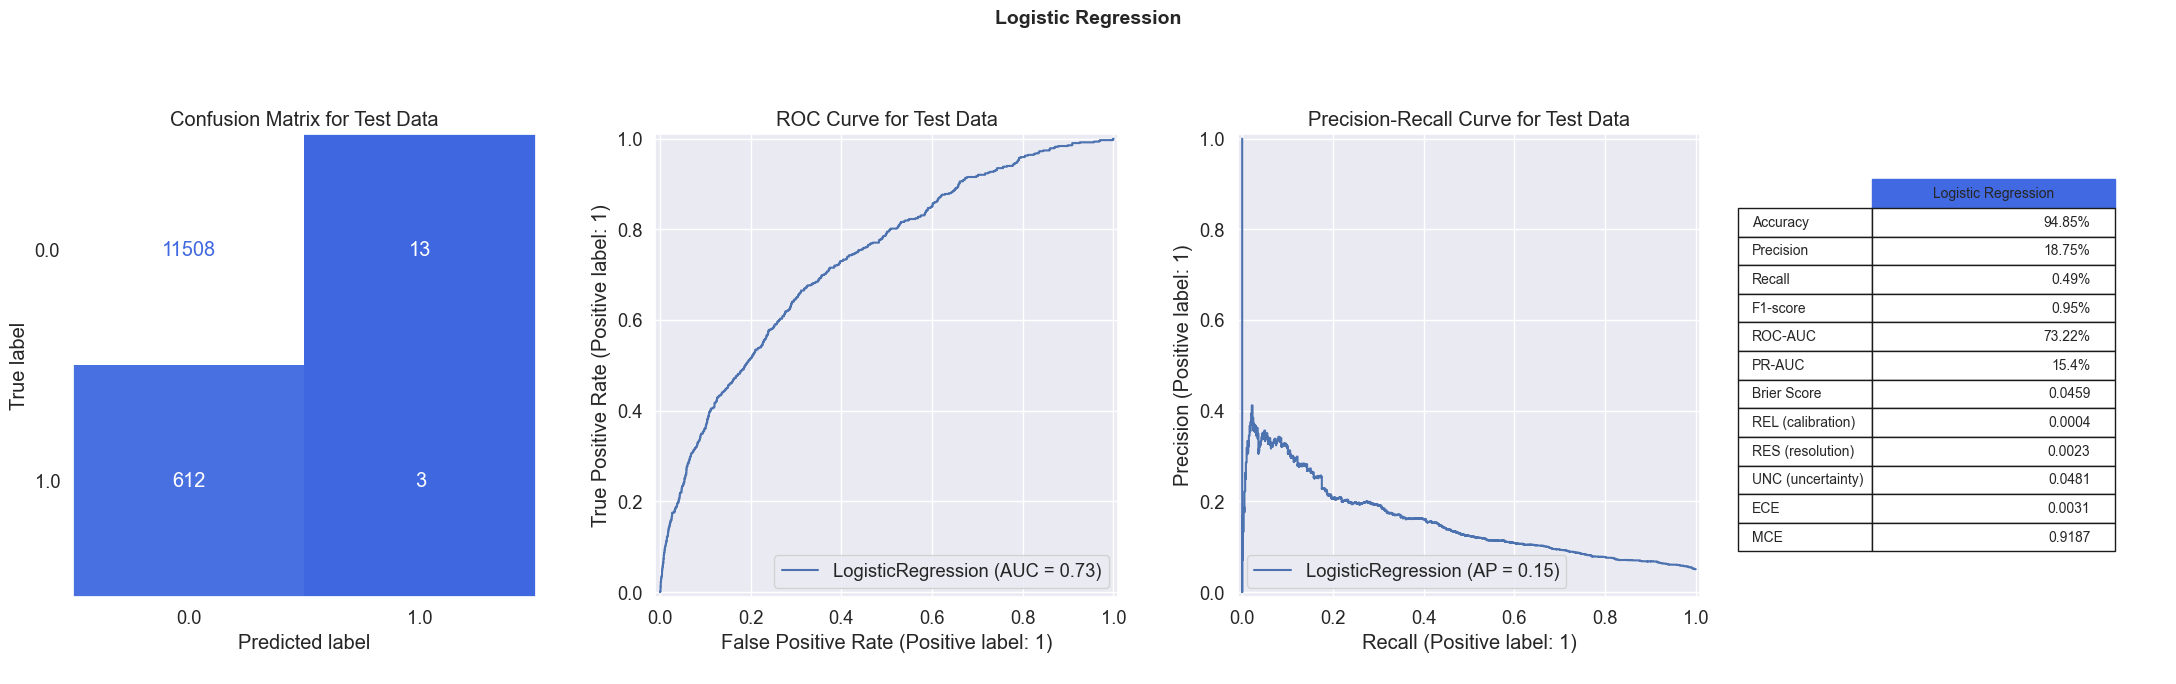

In [31]:
model_evaluation(best_lr, X_train_enc_df, X_test_enc_df, y_train, y_test,model_name='Logistic Regression')

In [28]:
#lets save the performance in  a table
lr_results = metrics_calculator(best_lr, X_test_enc_df, y_test, 'Logistic Regression')
lr_results

,Logistic Regression
Accuracy,94.85%
Precision,18.75%
Recall,0.49%
F1-score,0.95%
ROC-AUC,73.22%
PR-AUC,15.4%
Brier Score,0.0459
REL (calibration),0.0004
RES (resolution),0.0023
UNC (uncertainty),0.0481


In [76]:
fig=plot_calibration_curve(best_lr, X_test_enc_df, y_test, model_name='LR')

In [47]:
fig.write_html("lapse_calibration_curve_lgbm.html")

C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Brier Score — Uncalibrated: 0.0460
Brier Score — Calibrated:   0.0460
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0460               0.0460      0.0000               0.0%
REL (calibration)        0.0005               0.0004     -0.0001             -20.0%
RES (resolution)         0.0022               0.0023      0.0001              4.55%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0039               0.0052      0.0013             33.33%
MCE        0.9251               0.6364     -0.2887            -31.21%


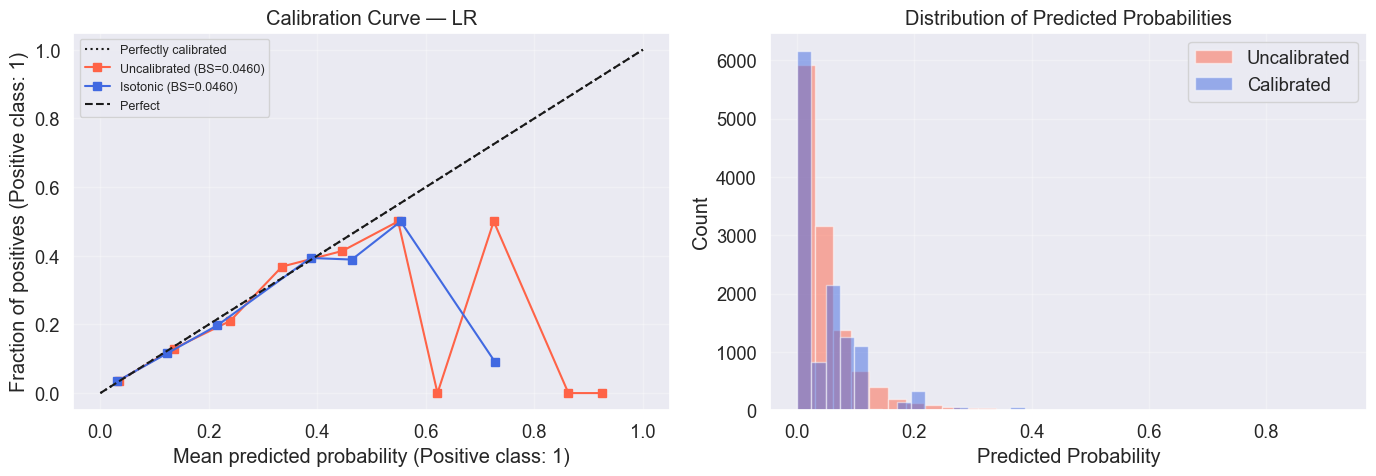

In [37]:
lr_res_cal, best_lr_cal = calibration_results(best_lr, X_train_enc_df, X_test_enc_df,
                                               y_train, y_test, model_name='LR')

In [38]:
best_lr_cal = CalibratedBundle(best_lr_cal['model'], best_lr_cal['isotonic'])

In [39]:
lr_cal_results = metrics_calculator(best_lr_cal, X_test_enc_df, y_test, 'Logistic Regression calib')
lr_cal_results

,Logistic Regression calib
Accuracy,94.87%
Precision,36.0%
Recall,1.46%
F1-score,2.81%
ROC-AUC,72.93%
PR-AUC,14.02%
Brier Score,0.046
REL (calibration),0.0004
RES (resolution),0.0023
UNC (uncertainty),0.0481


In [33]:
model_results = pd.concat([lr_results, lr_cal_results], axis=1)
model_results

,Logistic Regression,Logistic Regression calib
Accuracy,94.85%,94.87%
Precision,18.75%,36.0%
Recall,0.49%,1.46%
F1-score,0.95%,2.81%
ROC-AUC,73.22%,72.93%
PR-AUC,15.4%,14.02%
Brier Score,0.0459,0.046
REL (calibration),0.0004,0.0004
RES (resolution),0.0023,0.0023
UNC (uncertainty),0.0481,0.0481


In [45]:
fig2=evaluate_calibration_effect(best_lr, best_lr_cal, X_test_enc_df, y_test, model_name='Logistic Regression')

Brier Score — Uncalibrated (full train): 0.0459
Brier Score — Calibrated   (bundle):     0.0460
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0459      0.0460      0.0001              0.22%
REL (calibration)        0.0004      0.0004      0.0000               0.0%
RES (resolution)         0.0023      0.0023      0.0000               0.0%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.0031      0.0052      0.0021             67.74%
MCE        0.9187      0.6364     -0.2823            -30.73%


In [51]:
fig3 = plot_metrics_vs_threshold_interactive(best_lr, X_test_enc_df, y_test)
fig3.write_html("metrics_vs_threshold_lr.html")

In [48]:
fig2.write_html("calibration_curve_calvsuncal_lr.html")

## DT

	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0419
         0.0       0.95      1.00      0.97     46083         ROC-AUC            0.7975
         1.0       0.60      0.07      0.13      2458         PR-AUC             0.2625
                                                              ECE                0.0000
    accuracy                           0.95     48541       
   macro avg       0.77      0.53      0.55     48541       
weighted avg       0.93      0.95      0.93     48541       

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
     

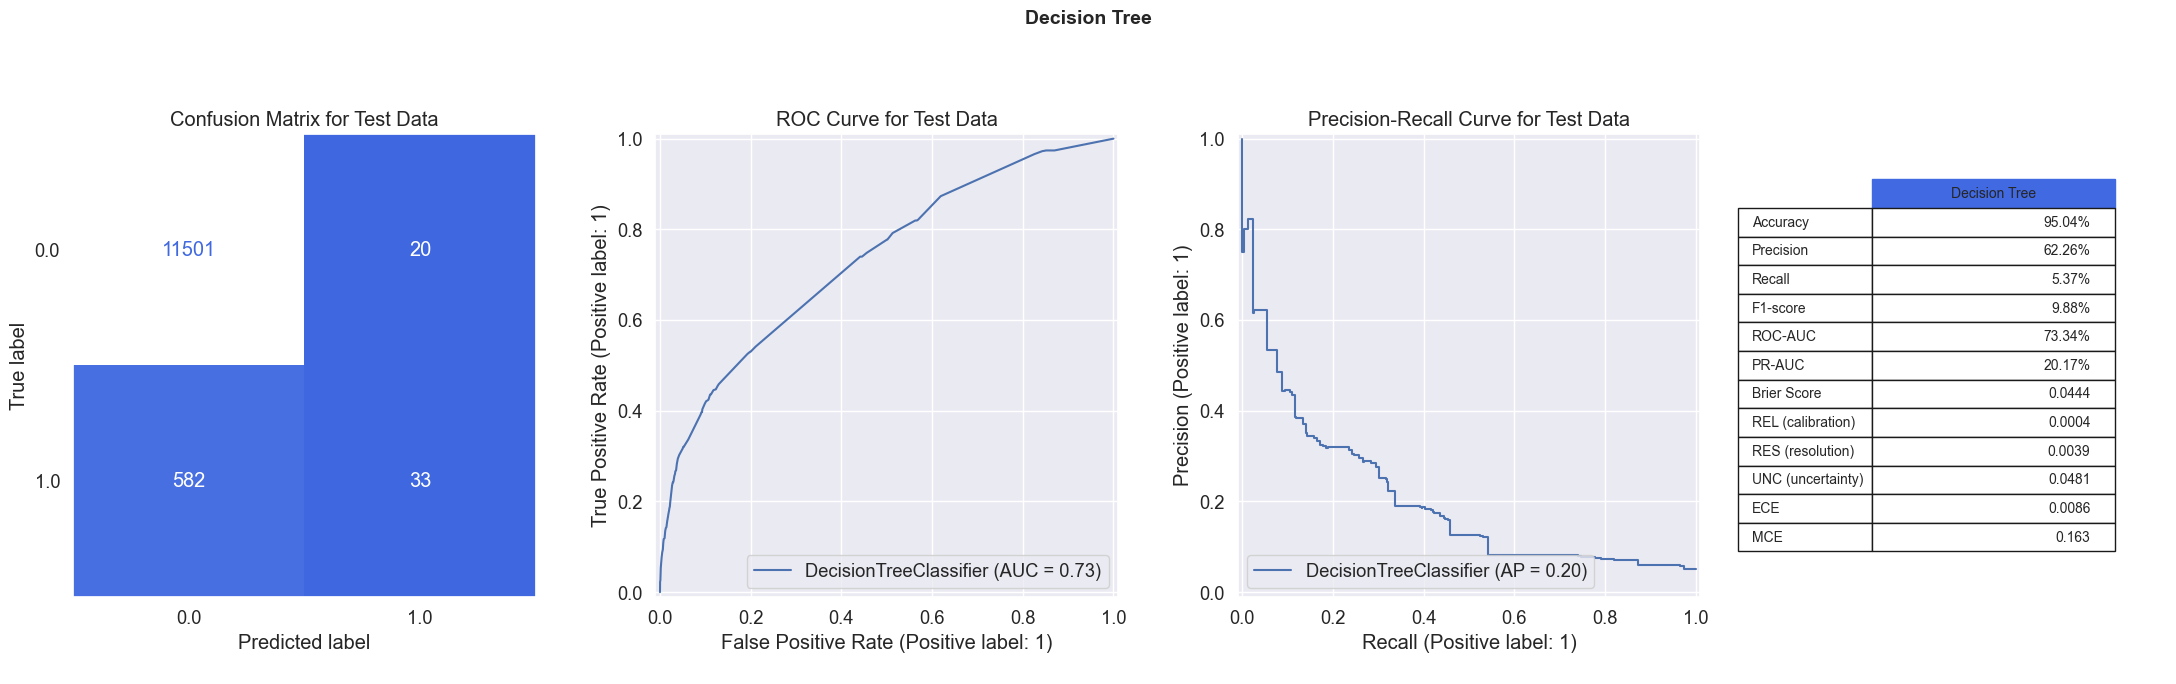

In [49]:
# optuna.logging.set_verbosity(optuna.logging.WARNING)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def objective_dt(trial):
#     params = {
#         'max_depth':        trial.suggest_int('max_depth', 3, 10),
#         'min_samples_split':trial.suggest_int('min_samples_split', 10, 200),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100),
#         'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#         'class_weight':     trial.suggest_categorical('class_weight', [None, 'balanced']),
#         'criterion':        trial.suggest_categorical('criterion', ['gini', 'entropy']),
#         'random_state':     42
#     }

#     model = DecisionTreeClassifier(**params)
#     scores = cross_val_score(
#         model,
#         X_train_enc_df,
#         y_train,
#         cv=cv,
#         scoring='neg_brier_score',
#         n_jobs=-1
#     )
#     return scores.mean()

# study_dt = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_dt.optimize(objective_dt, n_trials=20, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_dt.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_dt.best_params}")

# # Reconstruct and fit on full training set
# p = study_dt.best_params
# best_dt = DecisionTreeClassifier(**p)
# best_dt.fit(X_train_enc_df, y_train)

# model_evaluation(best_dt, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Decision Tree')   

# Best Brier Score: 0.0449
# Best hyperparameters:
# {'max_depth': 9, 'min_samples_split': 129, 'min_samples_leaf': 36, 'max_features': None, 'class_weight': None, 'criterion': 'gini'}


#calling the model with the above hyperparameters

best_dt = DecisionTreeClassifier(
    max_depth=9,
    min_samples_split=129,
    min_samples_leaf=36,
    max_features=None,
    class_weight=None,
    criterion='gini',
    random_state=42
)
best_dt.fit(X_train_enc_df, y_train)

model_evaluation(best_dt, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Decision Tree')





In [36]:
dt_results = metrics_calculator(best_dt, X_test_enc_df, y_test, 'Decision Tree')
dt_results

,Decision Tree
Accuracy,95.04%
Precision,62.26%
Recall,5.37%
F1-score,9.88%
ROC-AUC,73.34%
PR-AUC,20.17%
Brier Score,0.0444
REL (calibration),0.0004
RES (resolution),0.0039
UNC (uncertainty),0.0481


In [52]:
fig4=plot_metrics_vs_threshold_interactive(best_dt, X_test_enc_df, y_test)
fig4.write_html("metrics_vs_threshold_dt.html")

In [53]:
fig5=plot_calibration_curve(best_dt, X_test_enc_df, y_test, model_name='Decision Tree')
fig5.write_html("calibration_curve_dt.html")

Brier Score — Uncalibrated: 0.0451
Brier Score — Calibrated:   0.0450
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0451               0.0450     -0.0001             -0.22%
REL (calibration)        0.0005               0.0002     -0.0003             -60.0%
RES (resolution)         0.0034               0.0031     -0.0003             -8.82%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0094               0.0040     -0.0054            -57.45%
MCE        0.2336               0.2222     -0.0114             -4.88%


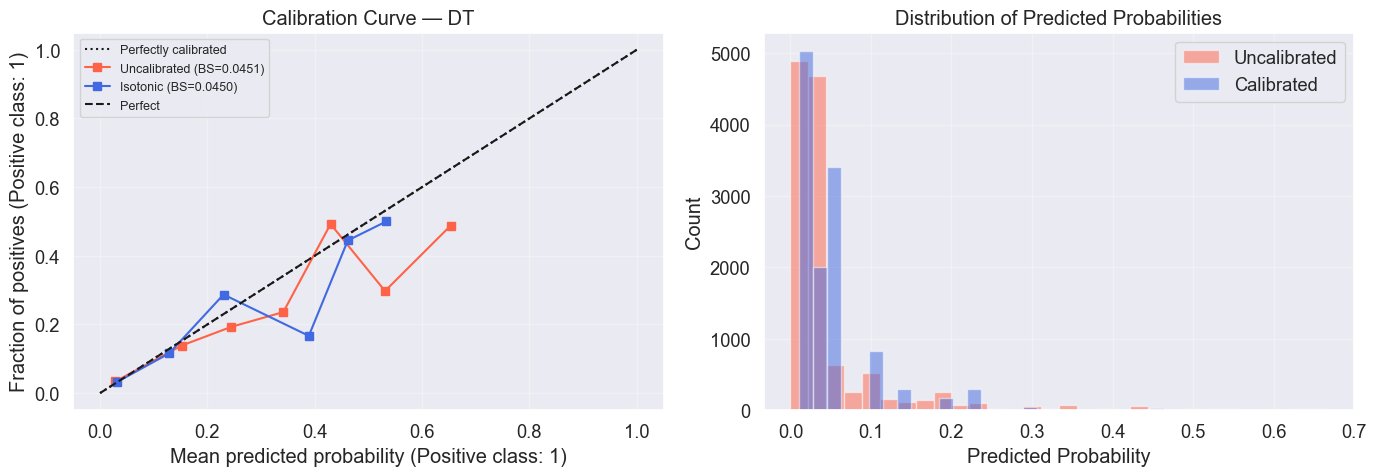

In [54]:
dt_res_cal, best_dt_cal = calibration_results(best_dt, X_train_enc_df, X_test_enc_df,
                                               y_train, y_test, model_name='DT')

# # At deployment:
# prob = best_dt_cal['isotonic'].predict(
#        best_dt_cal['model'].predict_proba(X_new)[:, 1])

Brier Score — Uncalibrated: 0.0451
Brier Score — Calibrated:   0.0450
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0451               0.0450     -0.0001             -0.22%
REL (calibration)        0.0005               0.0002     -0.0003             -60.0%
RES (resolution)         0.0034               0.0031     -0.0003             -8.82%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0094               0.0040     -0.0054            -57.45%
MCE        0.2336               0.2222     -0.0114             -4.88%


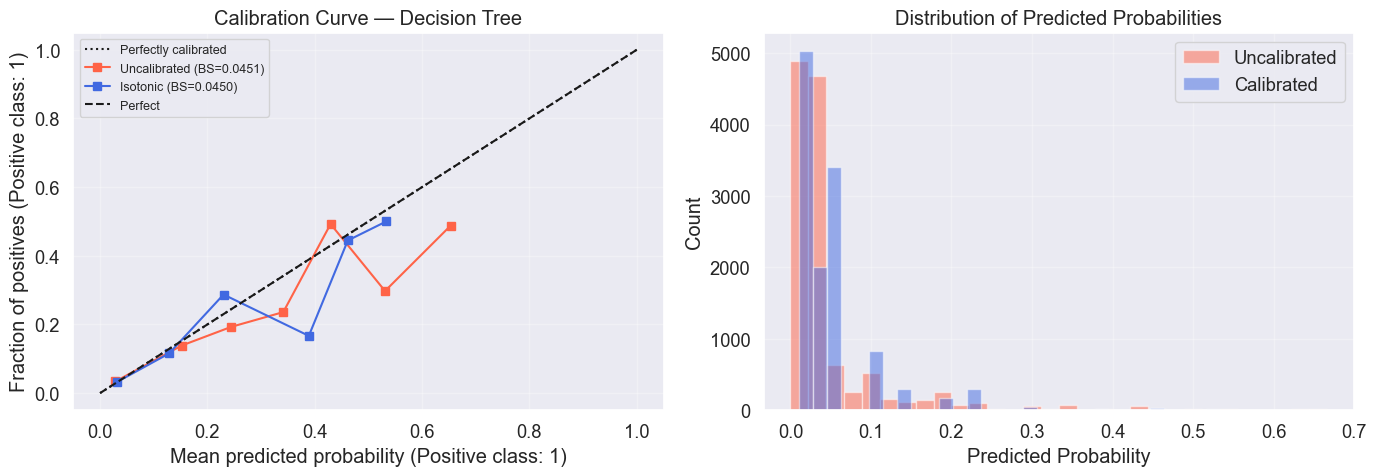

In [55]:
#now lets calibrate the decision tree

dt_res_cal, best_dt_cal = calibration_results(best_dt, X_train_enc_df, X_test_enc_df,
                                               y_train, y_test, model_name='Decision Tree')

best_dt_cal = CalibratedBundle(best_dt_cal['model'], best_dt_cal['isotonic'])

In [56]:
fig6=plot_calibration_curve(best_dt_cal, X_test_enc_df, y_test, model_name='Decision Tree')
fig6.write_html("calibration_curve_dt_cal.html")

In [57]:
fig7=evaluate_calibration_effect(best_dt, best_dt_cal, X_test_enc_df, y_test,
                             model_name='Decision Tree')
fig7.write_html("calibration_effect_dt.html")

Brier Score — Uncalibrated (full train): 0.0444
Brier Score — Calibrated   (bundle):     0.0450
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0444      0.0450      0.0006              1.35%
REL (calibration)        0.0004      0.0002     -0.0002             -50.0%
RES (resolution)         0.0039      0.0031     -0.0008            -20.51%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.0086      0.0040     -0.0046            -53.49%
MCE        0.1630      0.2222      0.0592             36.32%


In [43]:
dt_res_cal=metrics_calculator(best_dt_cal, X_test_enc_df, y_test, 'Decision Tree calib')
dt_res_cal

,Decision Tree calib
Accuracy,94.93%
Precision,50.0%
Recall,1.95%
F1-score,3.76%
ROC-AUC,71.85%
PR-AUC,16.37%
Brier Score,0.045
REL (calibration),0.0002
RES (resolution),0.0031
UNC (uncertainty),0.0481


In [44]:
model_results = pd.concat([model_results, dt_results, dt_res_cal], axis=1)

In [45]:
model_results

,Logistic Regression,Logistic Regression calib,Decision Tree,Decision Tree calib
Accuracy,94.85%,94.87%,95.04%,94.93%
Precision,18.75%,36.0%,62.26%,50.0%
Recall,0.49%,1.46%,5.37%,1.95%
F1-score,0.95%,2.81%,9.88%,3.76%
ROC-AUC,73.22%,72.93%,73.34%,71.85%
PR-AUC,15.4%,14.02%,20.17%,16.37%
Brier Score,0.0459,0.046,0.0444,0.045
REL (calibration),0.0004,0.0004,0.0004,0.0002
RES (resolution),0.0023,0.0023,0.0039,0.0031
UNC (uncertainty),0.0481,0.0481,0.0481,0.0481


## RF

In [58]:

#old code


# # calling the classifier
# rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# # defining a hyperparameter grid for random forest
# param_grid_rf = {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'criterion': ['gini', 'entropy']
# }

# best_rf, best_rf_hyperparams = tune_clf_hyperparameters(rf_base, param_grid_rf, X_train_enc_df, y_train, scoring='neg_brier_score')
# print('Random Forest Optimal Hyperparameters: \n', best_rf_hyperparams)

# model_evaluation(best_rf, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Random Forest')



#old code


# # calling the classifier
# rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# # defining a hyperparameter grid for random forest
# param_grid_rf = {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'criterion': ['gini', 'entropy']
# }

# best_rf, best_rf_hyperparams = tune_clf_hyperparameters(rf_base, param_grid_rf, X_train_enc_df, y_train, scoring='neg_brier_score')
# print('Random Forest Optimal Hyperparameters: \n', best_rf_hyperparams)

# model_evaluation(best_rf, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Random Forest')



#old code


# # calling the classifier
# rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# # defining a hyperparameter grid for random forest
# param_grid_rf = {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'criterion': ['gini', 'entropy']
# }

# best_rf, best_rf_hyperparams = tune_clf_hyperparameters(rf_base, param_grid_rf, X_train_enc_df, y_train, scoring='neg_brier_score')
# print('Random Forest Optimal Hyperparameters: \n', best_rf_hyperparams)

# # model_evaluation(best_rf, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Random Forest')
# Random Forest Optimal Hyperparameters: 
#  {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

# 	  Classification report for training set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       1.00      0.98      0.99     46083
#            1       0.74      0.97      0.84      2458

#     accuracy                           0.98     48541
#    macro avg       0.87      0.98      0.91     48541
# weighted avg       0.99      0.98      0.98     48541


# 	   Classification report for test set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       0.97      0.97      0.97     11521
#            1       0.45      0.38      0.41       615

#     accuracy                           0.94     12136
#    macro avg       0.71      0.68      0.69     12136
# weighted avg       0.94      0.94      0.94     12136



# new random forest with optuna
# first random forest with optuna overfitted a bit
# best_rf = RandomForestClassifier(
#     n_estimators=231, max_depth=12, min_samples_split=98,
#     min_samples_leaf=5, max_features='sqrt',
#     class_weight=None, criterion='entropy',
#     random_state=42, n_jobs=-1
# ) this where the best hp for the first hp grid 
# 	Run 1 (depth 3-15)	Run 2 (depth 3-8)
# Train ROC-AUC	0.9446	0.8445
# Test ROC-AUC	0.8205	0.7607
# ROC-AUC gap	-0.124 ⚠️	-0.084 ⚠️
# Brier gap	+0.0039 ✅	+0.0013 ✅

# RF struggles to simultaneously minimise overfitting and maximise discrimination on this imbalanced dataset — motivating the use of gradient boosting methods.

# optuna.logging.set_verbosity(optuna.logging.WARNING)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def objective_rf(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 200, 500),
#         'max_depth':         trial.suggest_int('max_depth', 3, 8),       # ← was 3-15
#         'min_samples_split': trial.suggest_int('min_samples_split', 10, 200),
#         'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 100), # ← min raised
#         'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
#         'max_samples':       trial.suggest_float('max_samples', 0.6, 0.9), # ← new: row subsampling
#         'class_weight':      trial.suggest_categorical('class_weight', [None, 'balanced']),
#         'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy']),
#         'random_state':      42,
#         'n_jobs':            -1
#     }
#     model = RandomForestClassifier(**params)
#     scores = cross_val_score(model, X_train_enc_df, y_train,
#                              cv=cv, scoring='neg_brier_score', n_jobs=-1)
#     return scores.mean()

# study_rf = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_rf.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_rf.best_params}")

# # Reconstruct and fit on full training set
# best_rf = RandomForestClassifier(**study_rf.best_params)
# best_rf.fit(X_train_enc_df, y_train)

# model_evaluation(best_rf, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Random Forest')



# Best Brier Score: 0.0456
# Best hyperparameters:
# {'n_estimators': 396, 'max_depth': 8, 'min_samples_split': 174, 'min_samples_leaf': 72, 'max_features': 'sqrt', 'max_samples': 0.8771310857661102, 'class_weight': None, 'criterion': 'entropy'}


best_rf =  RandomForestClassifier(
    n_estimators=396, max_depth=8, min_samples_split=174,
    min_samples_leaf=72, max_features='sqrt', max_samples=0.8771310857661102,
    class_weight=None, criterion='entropy', random_state=42, n_jobs=-1
)


best_rf.fit(X_train_enc_df, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",396
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",174
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",72
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0444
         0.0       0.95      1.00      0.97     46083         ROC-AUC            0.8477
         1.0       0.00      0.00      0.00      2458         PR-AUC             0.2749
                                                              ECE                0.0178
    accuracy                           0.95     48541       
   macro avg       0.47      0.50      0.49     48541       
weighted avg       0.90      0.95      0.92     48541       



C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Test Probability Metrics
                                                              Brier Score        0.0457
         0.0       0.95      1.00      0.97     11521         ROC-AUC            0.7653
         1.0       0.00      0.00      0.00       615         PR-AUC             0.1808
                                                              ECE                0.0086
    accuracy                           0.95     12136         Overfitting Check (Test - Train)
   macro avg       0.47      0.50      0.49     12136         Brier gap          +0.0014  ✅
weighted avg       0.90      0.95      0.92     12136         ROC-AUC gap        -0.0823  ⚠️



C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


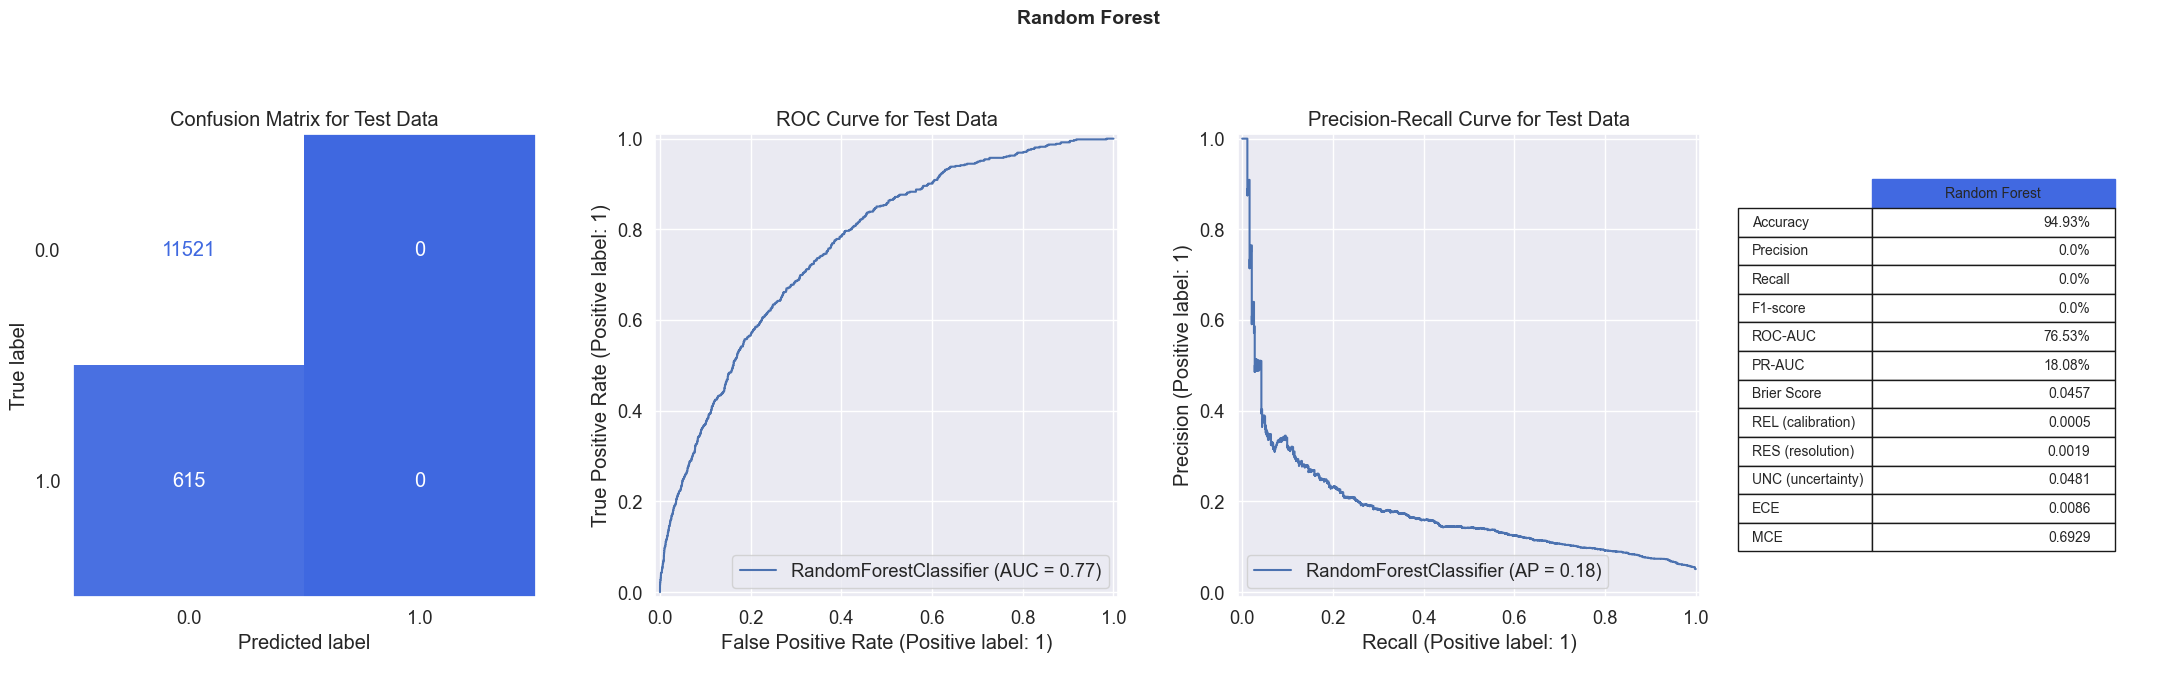

In [59]:
model_evaluation(best_rf, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='Random Forest')

In [77]:
plot_metrics_vs_threshold_interactive(best_rf, X_test_enc_df, y_test)

In [48]:
rf_results = metrics_calculator(best_rf, X_test_enc_df, y_test, 'Random Forest')
rf_results

C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Random Forest
Accuracy,94.93%
Precision,0.0%
Recall,0.0%
F1-score,0.0%
ROC-AUC,76.53%
PR-AUC,18.08%
Brier Score,0.0457
REL (calibration),0.0005
RES (resolution),0.0019
UNC (uncertainty),0.0481


In [60]:
fig8=plot_calibration_curve(best_rf, X_test_enc_df, y_test, model_name='Random Forest')
fig8.write_html("calibration_curve_rf.html")

Brier Score — Uncalibrated: 0.0459
Brier Score — Calibrated:   0.0454
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0459               0.0454     -0.0005             -1.09%
REL (calibration)        0.0005               0.0003     -0.0002             -40.0%
RES (resolution)         0.0019               0.0023      0.0004             21.05%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0090               0.0066     -0.0024            -26.67%
MCE        0.3739               0.5095      0.1356             36.27%


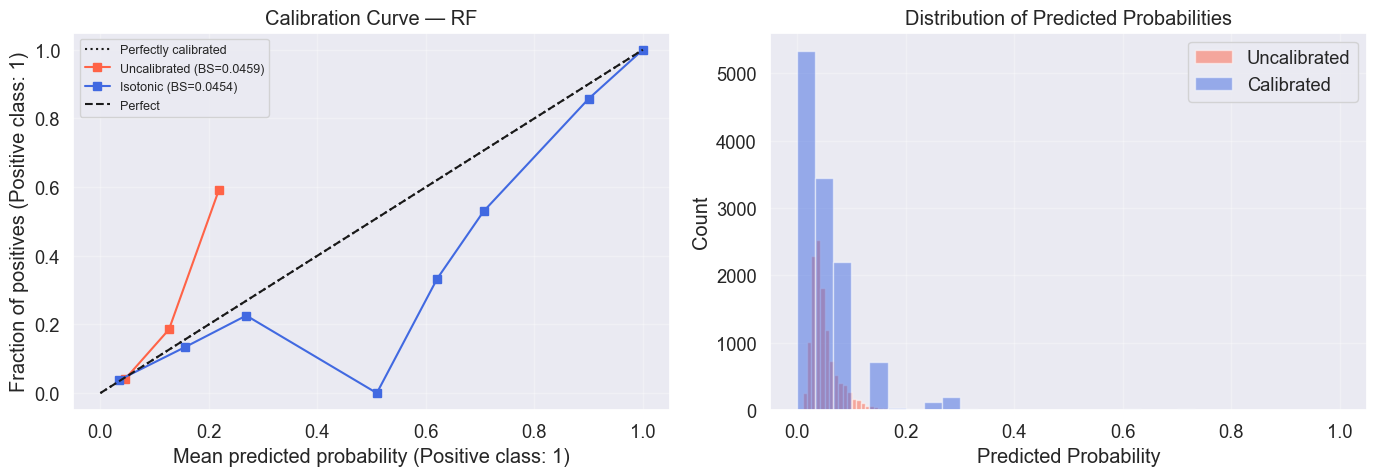

In [61]:
rf_res_cal, best_rf_cal = calibration_results(best_rf, X_train_enc_df, X_test_enc_df,
                                               y_train, y_test, model_name='RF')

In [62]:
#getting the calibrated classifier
best_rf_cal = CalibratedBundle(best_rf_cal['model'], best_rf_cal['isotonic'])
fig9=plot_calibration_curve(best_rf_cal, X_test_enc_df, y_test, model_name='Random Forest')
fig9.write_html("calibration_curve_rf_cal.html")


In [63]:
fig10=evaluate_calibration_effect(best_rf, best_rf_cal, X_test_enc_df, y_test, model_name='Random Forest')
fig10.write_html("calibration_effect_rf.html")

Brier Score — Uncalibrated (full train): 0.0457
Brier Score — Calibrated   (bundle):     0.0454
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0457      0.0454     -0.0003             -0.66%
REL (calibration)        0.0005      0.0003     -0.0002             -40.0%
RES (resolution)         0.0019      0.0023      0.0004             21.05%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.0086      0.0066     -0.0020            -23.26%
MCE        0.6929      0.5095     -0.1834            -26.47%


In [53]:
rf_res_cal=metrics_calculator(best_rf_cal, X_test_enc_df, y_test, 'Random Forest calib')
rf_res_cal

,Random Forest calib
Accuracy,94.94%
Precision,51.22%
Recall,3.41%
F1-score,6.4%
ROC-AUC,75.41%
PR-AUC,15.91%
Brier Score,0.0454
REL (calibration),0.0003
RES (resolution),0.0023
UNC (uncertainty),0.0481


In [54]:
model_results = pd.concat([model_results, rf_results ,rf_res_cal], axis=1)
model_results

,Logistic Regression,Logistic Regression calib,Decision Tree,Decision Tree calib,Random Forest,Random Forest calib
Accuracy,94.85%,94.87%,95.04%,94.93%,94.93%,94.94%
Precision,18.75%,36.0%,62.26%,50.0%,0.0%,51.22%
Recall,0.49%,1.46%,5.37%,1.95%,0.0%,3.41%
F1-score,0.95%,2.81%,9.88%,3.76%,0.0%,6.4%
ROC-AUC,73.22%,72.93%,73.34%,71.85%,76.53%,75.41%
PR-AUC,15.4%,14.02%,20.17%,16.37%,18.08%,15.91%
Brier Score,0.0459,0.046,0.0444,0.045,0.0457,0.0454
REL (calibration),0.0004,0.0004,0.0004,0.0002,0.0005,0.0003
RES (resolution),0.0023,0.0023,0.0039,0.0031,0.0019,0.0023
UNC (uncertainty),0.0481,0.0481,0.0481,0.0481,0.0481,0.0481


## XGBOOST

In [64]:
# # # calling the classifier
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# xgboost_base = xgb.XGBClassifier(
#     random_state=42,
#     n_jobs=-1,
#     eval_metric='logloss',
#     scale_pos_weight=scale_pos_weight
# )

# # defining the hp grid
# param_grid_xgb = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators':  [100, 200, 300],
#     'max_depth':     [3, 6],
#     'subsample':     [0.8, 1.0],
# }

# best_xgb, best_xgb_hyperparams = tune_clf_hyperparameters(xgboost_base, param_grid_xgb, X_train_enc_df, y_train, scoring='neg_brier_score')
# print('XGBoost Optimal Hyperparameters: \n', best_xgb_hyperparams)

# model_evaluation(best_xgb, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='XGBoost')


# XGBoost Optimal Hyperparameters: 
#  {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}

# 	  Classification report for training set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       1.00      0.97      0.98     46083
#            1       0.61      1.00      0.76      2458

#     accuracy                           0.97     48541
#    macro avg       0.81      0.98      0.87     48541
# weighted avg       0.98      0.97      0.97     48541


# 	   Classification report for test set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       0.98      0.95      0.97     11521
#            1       0.41      0.63      0.50       615

#     accuracy                           0.94     12136
#    macro avg       0.70      0.79      0.73     12136
# weighted avg       0.95      0.94      0.94     12136
# 	XGBoost
# Accuracy	93.62%
# Precision	41.5%
# Recall	63.09%
# F1-score	50.06%
# ROC-AUC	88.76%
# PR-AUC	51.46%
# Brier Score	0.0546
# REL (calibration)	0.0215
# RES (resolution)	0.015
# UNC (uncertainty)	0.0481
# ECE	0.0973
# MCE	0.4025



# now lets use optuna to yune the xgboost

# optuna.logging.set_verbosity(optuna.logging.WARNING)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# def objective_xgb(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
#         'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'max_depth':         trial.suggest_int('max_depth', 3, 10),
#         'min_child_weight':  trial.suggest_int('min_child_weight', 5, 100),
#         'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
#         'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
#         'scale_pos_weight':  scale_pos,
#         'objective':         'binary:logistic',
#         'eval_metric':       'logloss',
#         'random_state':      42,
#         'n_jobs':            -1,
#         'verbosity':         0,
#     }

#     model = xgb.XGBClassifier(**params)
#     scores = cross_val_score(
#         model,
#         X_train_enc_df,
#         y_train,
#         cv=cv,
#         scoring='neg_brier_score',
#         n_jobs=-1
#     )
#     return scores.mean()

# study_xgb = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_xgb.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_xgb.best_params}")

# # Reconstruct and fit on full training set
# best_xgb = xgb.XGBClassifier(
#     **study_xgb.best_params,
#     scale_pos_weight=scale_pos,
#     objective='binary:logistic',
#     eval_metric='logloss',
#     random_state=42,
#     n_jobs=-1,
#     verbosity=0
# )
# best_xgb.fit(X_train_enc_df, y_train)







#calling th emodels with the best hyper parameters from the opruna 
# Best Brier Score: 0.0320
# Best hyperparameters:
# {'n_estimators': 598, 'learning_rate': 0.13884254435609056, 'max_depth': 9, 'min_child_weight': 20, 'subsample': 0.6795331396319276, 'colsample_bytree': 0.8730691549031337, 'reg_alpha': 0.5393711133815272, 'reg_lambda': 0.12474104742082552}


best_XGB = xgb.XGBClassifier(
    n_estimators=598,
    learning_rate=0.13884254435609056,
    max_depth=9,
    min_child_weight=20,
    subsample=0.6795331396319276,
    colsample_bytree=0.8730691549031337,
    reg_alpha=0.5393711133815272,
    reg_lambda=0.12474104742082552,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,    
    n_jobs=-1)

#fitting it to the data 
best_XGB.fit(X_train_enc_df, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8730691549031337
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0047
         0.0       1.00      1.00      1.00     46083         ROC-AUC            0.9999
         1.0       1.00      0.94      0.97      2458         PR-AUC             0.9990
                                                              ECE                0.0225
    accuracy                           1.00     48541       
   macro avg       1.00      0.97      0.98     48541       
weighted avg       1.00      1.00      1.00     48541       

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
     

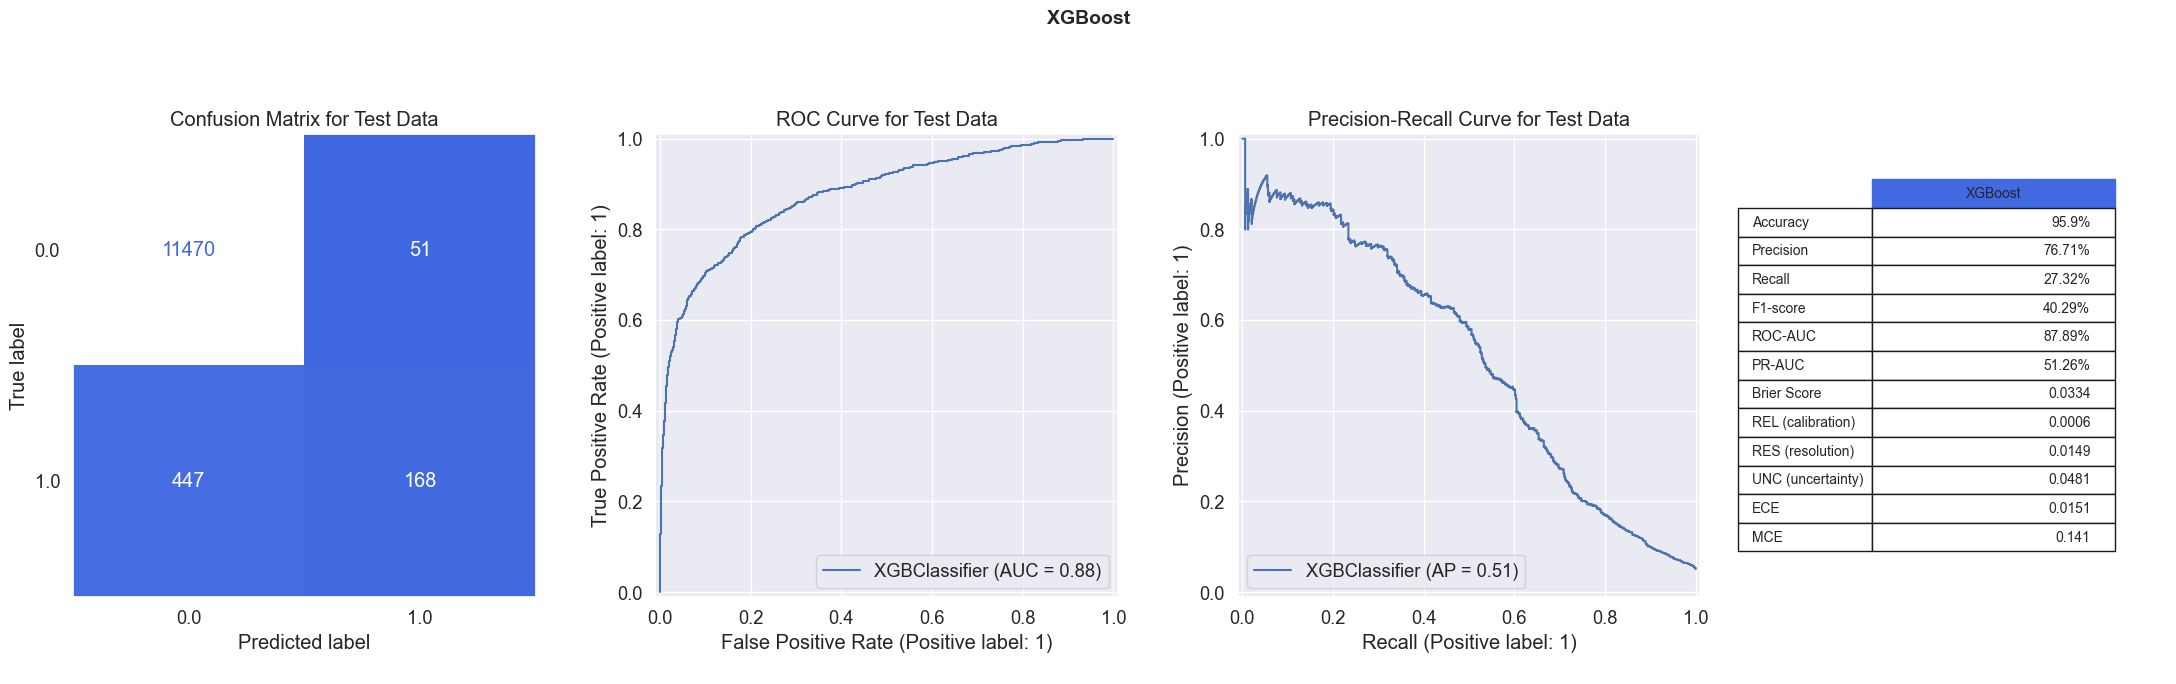

In [65]:
model_evaluation(best_XGB, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='XGBoost')

In [78]:
plot_metrics_vs_threshold_interactive(best_XGB, X_test_enc_df, y_test)

In [66]:
fig11=plot_calibration_curve(best_XGB, X_test_enc_df, y_test, model_name='XGBoost')
fig11.write_html("calibration_curve_xgb.html")


Brier Score — Uncalibrated: 0.0354
Brier Score — Calibrated:   0.0353
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0354               0.0353     -0.0001             -0.28%
REL (calibration)        0.0004               0.0003     -0.0001             -25.0%
RES (resolution)         0.0127               0.0125     -0.0002             -1.57%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0157               0.0057     -0.0100            -63.69%
MCE        0.1334               0.6337      0.5003            375.04%


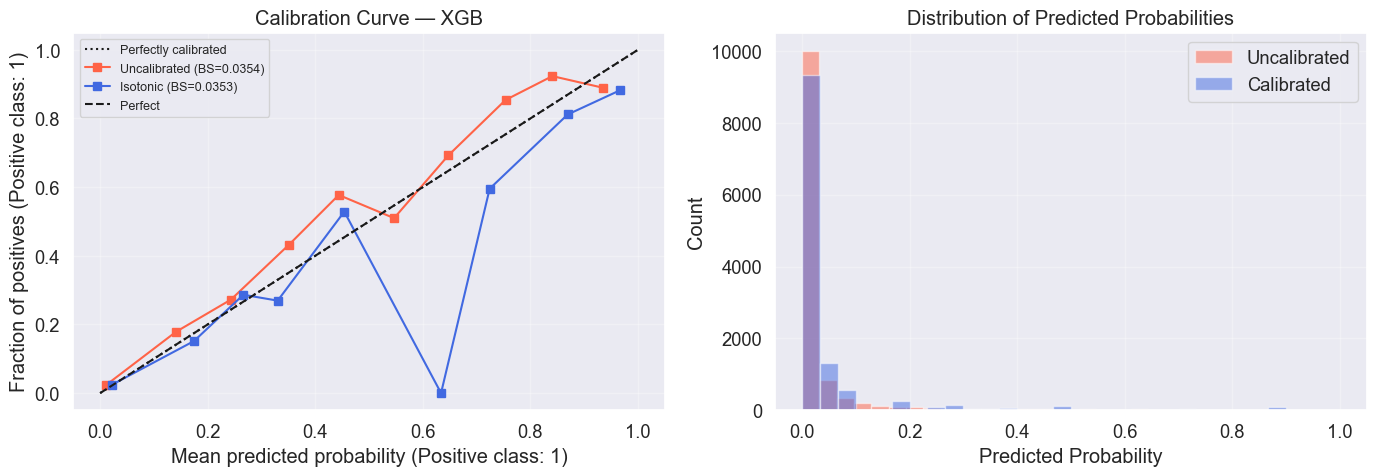

In [67]:
XGB_res_cal, best_XGB_cal = calibration_results(best_XGB, X_train_enc_df, X_test_enc_df,
                                                   y_train, y_test, model_name='XGB')

In [68]:
best_XGB_cal = CalibratedBundle(best_XGB_cal['model'], best_XGB_cal['isotonic'])
fig12=plot_calibration_curve(best_XGB_cal, X_test_enc_df, y_test, model_name='XGBoost')
fig12.write_html("calibration_curve_xgb_cal.html")

In [69]:
fig13=evaluate_calibration_effect(best_XGB, best_XGB_cal, X_test_enc_df, y_test, model_name='XGBoost')
fig13.write_html("calibration_effect_xgb.html")


Brier Score — Uncalibrated (full train): 0.0334
Brier Score — Calibrated   (bundle):     0.0353
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0334      0.0353      0.0019              5.69%
REL (calibration)        0.0006      0.0003     -0.0003             -50.0%
RES (resolution)         0.0149      0.0125     -0.0024            -16.11%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.0151      0.0057     -0.0094            -62.25%
MCE        0.1410      0.6337      0.4927            349.43%


In [61]:
xgb_results = metrics_calculator(best_XGB, X_test_enc_df, y_test, 'XGBoost')
xgb_results
XGB_res_cal=metrics_calculator(best_XGB_cal, X_test_enc_df, y_test, 'XGBoost calib')
XGB_res_cal

model_results = pd.concat([model_results, xgb_results, XGB_res_cal], axis=1)
model_results

,Logistic Regression,Logistic Regression calib,Decision Tree,Decision Tree calib,Random Forest,Random Forest calib,XGBoost,XGBoost calib
Accuracy,94.85%,94.87%,95.04%,94.93%,94.93%,94.94%,95.9%,95.64%
Precision,18.75%,36.0%,62.26%,50.0%,0.0%,51.22%,76.71%,75.9%
Recall,0.49%,1.46%,5.37%,1.95%,0.0%,3.41%,27.32%,20.49%
F1-score,0.95%,2.81%,9.88%,3.76%,0.0%,6.4%,40.29%,32.27%
ROC-AUC,73.22%,72.93%,73.34%,71.85%,76.53%,75.41%,87.89%,85.83%
PR-AUC,15.4%,14.02%,20.17%,16.37%,18.08%,15.91%,51.26%,43.22%
Brier Score,0.0459,0.046,0.0444,0.045,0.0457,0.0454,0.0334,0.0353
REL (calibration),0.0004,0.0004,0.0004,0.0002,0.0005,0.0003,0.0006,0.0003
RES (resolution),0.0023,0.0023,0.0039,0.0031,0.0019,0.0023,0.0149,0.0125
UNC (uncertainty),0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481


## lgbm

In [25]:

# # calling the model constructor for lightgbm
# lightgbm_base = LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, n_jobs=-1, objective='binary')

# # defining the hp grid
# param_grid = {
#     "n_estimators":      [200, 500],
#     "learning_rate":     [0.05, 0.1],
#     "max_depth":         [6, 8],
#     "num_leaves":        [31, 63],
#     "min_child_samples": [50, 100],
#     "reg_lambda":        [0.1, 1.0],
#     "subsample":         [0.8],
#     "colsample_bytree":  [0.8],
# }

# best_lgbm, best_lgbm_hyperparams = tune_clf_hyperparameters(lightgbm_base, param_grid, X_train_enc_df, y_train, scoring='neg_brier_score')
# print('lgbm Optimal Hyperparameters: \n', best_lgbm_hyperparams)

# model_evaluation(best_lgbm, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='LightGBM')

# 	  Classification report for training set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       1.00      1.00      1.00     46083
#            1       0.96      1.00      0.98      2458

#     accuracy                           1.00     48541
#    macro avg       0.98      1.00      0.99     48541
# weighted avg       1.00      1.00      1.00     48541


# 	   Classification report for test set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       0.98      0.98      0.98     11521
#            1       0.67      0.57      0.62       615

#     accuracy                           0.96     12136
#    macro avg       0.82      0.78      0.80     12136
# weighted avg       0.96      0.96      0.96     12136



# 	LightGBM
# Accuracy	96.39%
# Precision	66.86%
# Recall	57.07%
# F1-score	61.58%
# ROC-AUC	89.69%
# PR-AUC	64.57%
# Brier Score	0.0295
# REL (calibration)	0.0023
# RES (resolution)	0.0209
# UNC (uncertainty)	0.0481
# ECE	0.0155
# MCE	0.2583

#now lets do optuna tunning 

optuna.logging.set_verbosity(optuna.logging.WARNING)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

def objective_lgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'scale_pos_weight':  scale_pos,
        'random_state':      42,
        'n_jobs':            -1,
        'verbosity':         -1,
    }

    model = LGBMClassifier(**params)
    scores = cross_val_score(
        model,
        X_train_enc_df,
        y_train,
        cv=cv,
        scoring='neg_brier_score',
        n_jobs=-1
    )
    return scores.mean()

study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_lgbm.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)

print(f"\nBest Brier Score: {-study_lgbm.best_value:.4f}")
print(f"Best hyperparameters:\n{study_lgbm.best_params}")

# Reconstruct and fit on full training set
best_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
best_lgbm.fit(X_train_enc_df, y_train)

# model_evaluation(best_lgbm, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='LightGBM')
# # lgbm_res_cal, best_lgbm_cal = calibration_results(best_lgbm, X_train_enc_df, X_test_enc_df,
# #                                                     y_train, y_test, model_name='LGBM')





# Best Brier Score: 0.0289
# Best hyperparameters:
# {'n_estimators': 598, 'learning_rate': 0.0818438922297831, 'num_leaves': 57, 'max_depth': 10, 'min_child_samples': 58, 'subsample': 0.8513496163789993, 'colsample_bytree': 0.5055111967492395, 'reg_alpha': 0.0009706016345215861, 'reg_lambda': 0.0014029371029987783}
# 	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
# -------------------------------------------------------     -----------------------------------
#               precision    recall  f1-score   support         Train Probability Metrics
#                                                               Brier Score        0.0029
#            0       1.00      1.00      1.00     46083         ROC-AUC            1.0000
#            1       0.97      1.00      0.99      2458         PR-AUC             1.0000
#                                                               ECE                0.0211
#     accuracy                           1.00     48541       
#    macro avg       0.99      1.00      0.99     48541       
# weighted avg       1.00      1.00      1.00     48541       

# 	 Classification report — TEST                              	 Probability Metrics — TEST
# -------------------------------------------------------     -----------------------------------
#               precision    recall  f1-score   support         Test Probability Metrics
#                                                               Brier Score        0.0278
#            0       0.98      0.99      0.98     11521         ROC-AUC            0.9056
#            1       0.71      0.56      0.63       615         PR-AUC             0.6663
#                                                               ECE                0.0126
#     accuracy                           0.97     12136         Overfitting Check (Test - Train)
#    macro avg       0.84      0.78      0.81     12136         Brier gap          +0.0248  ⚠️
# weighted avg       0.96      0.97      0.96     12136         ROC-AUC gap        -0.0944  ⚠️

# this values for the brier score  and roc and pr AUC is too much in the train data 



#lets do another optuna strudy to smooth pit overfit


# def objective_lgbm(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 100, 400),      # was 598 → cap lower
#         'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'num_leaves':        trial.suggest_int('num_leaves', 20, 50),           # was 57 → reduce
#         'max_depth':         trial.suggest_int('max_depth', 4, 8),              # was 10 → shallower
#         'min_child_samples': trial.suggest_int('min_child_samples', 50, 200),   # more regularisation
#         'subsample':         trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 0.9),
#         'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 1.0, log=True),  # stronger L1
#         'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 1.0, log=True), # stronger L2
#     }

#     model = LGBMClassifier(
#         **params,
#         scale_pos_weight=scale_pos,
#         random_state=42,
#         n_jobs=-1,
#         verbosity=-1
#     )

#     cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#     scores = cross_val_score(model, X_train_enc_df, y_train,
#                              cv=cv, scoring='neg_brier_score', n_jobs=-1)
#     return scores.mean()

# study_lgbm2 = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_lgbm2.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_lgbm2.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_lgbm2.best_params}")

# best_lgbm = LGBMClassifier(
#     **study_lgbm2.best_params,
#     scale_pos_weight=scale_pos,
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1
# )
# best_lgbm.fit(X_train_enc_df, y_train)

# model_evaluation(best_lgbm, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='LightGBM')

# Best Brier Score: 0.0515
# Best hyperparameters:
# {'n_estimators': 372, 'learning_rate': 0.060301848022058964, 'num_leaves': 47, 'max_depth': 8, 'min_child_samples': 118, 'subsample': 0.7708709402685341, 'colsample_bytree': 0.5575105392108679, 'reg_alpha': 0.272357134407874, 'reg_lambda': 0.9510063848078801}
# 	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
# -------------------------------------------------------     -----------------------------------
#               precision    recall  f1-score   support         Train Probability Metrics
#                                                               Brier Score        0.0354
#            0       1.00      0.96      0.98     46083         ROC-AUC            0.9980
#            1       0.60      1.00      0.75      2458         PR-AUC             0.9572
#                                                               ECE                0.1066
#     accuracy                           0.97     48541       
#    macro avg       0.80      0.98      0.86     48541       
# weighted avg       0.98      0.97      0.97     48541       

# 	 Classification report — TEST                              	 Probability Metrics — TEST
# -------------------------------------------------------     -----------------------------------
#               precision    recall  f1-score   support         Test Probability Metrics
#                                                               Brier Score        0.0556
#            0       0.98      0.95      0.97     11521         ROC-AUC            0.8973
#            1       0.41      0.67      0.51       615         PR-AUC             0.5365
#                                                               ECE                0.1045
#     accuracy                           0.94     12136         Overfitting Check (Test - Train)
#    macro avg       0.70      0.81      0.74     12136         Brier gap          +0.0202  ⚠️
# weighted avg       0.95      0.94      0.94     12136         ROC-AUC gap        -0.1007  ⚠️




# clearl it does have not compensate to rerun with the more conservative grid so  lets keep the first one 
#Best hyperparameters:
# {'n_estimators': 372, 'learning_rate': 0.060301848022058964, 'num_leaves': 47, 'max_depth': 8, 'min_child_samples': 118, 'subsample': 0.7708709402685341, 'colsample_bytree': 0.5575105392108679, 'reg_alpha': 0.272357134407874, 'reg_lambda': 0.9510063848078801}
# best_lgbm = LGBMClassifier(
#     n_estimators=598,
#     learning_rate=0.0818438922297831,
#     num_leaves=57,
#     max_depth=10,
#     min_child_samples=58,
#     subsample=0.8513496163789993,
#     colsample_bytree=0.5055111967492395,
#     reg_alpha=0.0009706016345215861,
#     reg_lambda=0.0014029371029987783,
#     #scale_pos_weight=scale_pos,
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1
# )
# best_lgbm.fit(X_train_enc_df, y_train)

# model_evaluation(best_lgbm, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='LightGBM')









  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 11. Best value: -0.0288548: 100%|██████████| 20/20 [08:52<00:00, 26.63s/it]



Best Brier Score: 0.0289
Best hyperparameters:
{'n_estimators': 598, 'learning_rate': 0.0818438922297831, 'num_leaves': 57, 'max_depth': 10, 'min_child_samples': 58, 'subsample': 0.8513496163789993, 'colsample_bytree': 0.5055111967492395, 'reg_alpha': 0.0009706016345215861, 'reg_lambda': 0.0014029371029987783}


,boosting_type,'gbdt'
,num_leaves,57
,max_depth,10
,learning_rate,0.0818438922297831
,n_estimators,598
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,58


C:\Users\e982233\AppData\Local\Temp\ipykernel_27212\2403421276.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_plt.plot_optimization_history(study_lgbm)


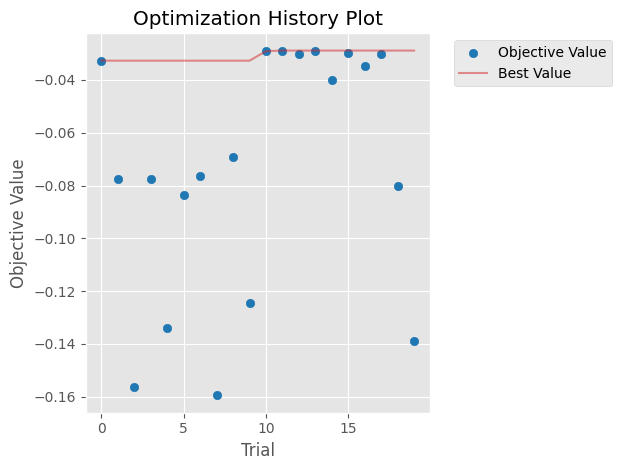

In [29]:
import optuna.visualization.matplotlib as optuna_plt
optuna_plt.plot_optimization_history(study_lgbm)
plt.tight_layout(); plt.show()

In [31]:



import optuna.visualization as vis
vis.plot_optimization_history(study_lgbm)


In [32]:
vis.plot_param_importances(study_lgbm)

In [35]:
vis.plot_slice(study_lgbm)

In [36]:
vis.plot_parallel_coordinate(study_lgbm)

In [37]:
plot_metrics_vs_threshold_interactive(best_lgbm, X_test_enc_df, y_test)

In [63]:
lgbm_results = metrics_calculator(best_lgbm, X_test_enc_df, y_test, 'LightGBM')
lgbm_results

,LightGBM
Accuracy,96.72%
Precision,90.04%
Recall,39.67%
F1-score,55.08%
ROC-AUC,90.39%
PR-AUC,68.22%
Brier Score,0.0269
REL (calibration),0.0018
RES (resolution),0.0225
UNC (uncertainty),0.0481


In [79]:
fig14=plot_calibration_curve(best_lgbm, X_test_enc_df, y_test, model_name='LightGBM')
fig14.write_html("calibration_curve_lgbm.html")


Brier Score — Uncalibrated: 0.0299
Brier Score — Calibrated:   0.0294
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0299               0.0294     -0.0005             -1.67%
REL (calibration)        0.0008               0.0001     -0.0007             -87.5%
RES (resolution)         0.0189               0.0187     -0.0002             -1.06%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0146               0.0027     -0.0119            -81.51%
MCE        0.2005               0.1415     -0.0590            -29.43%


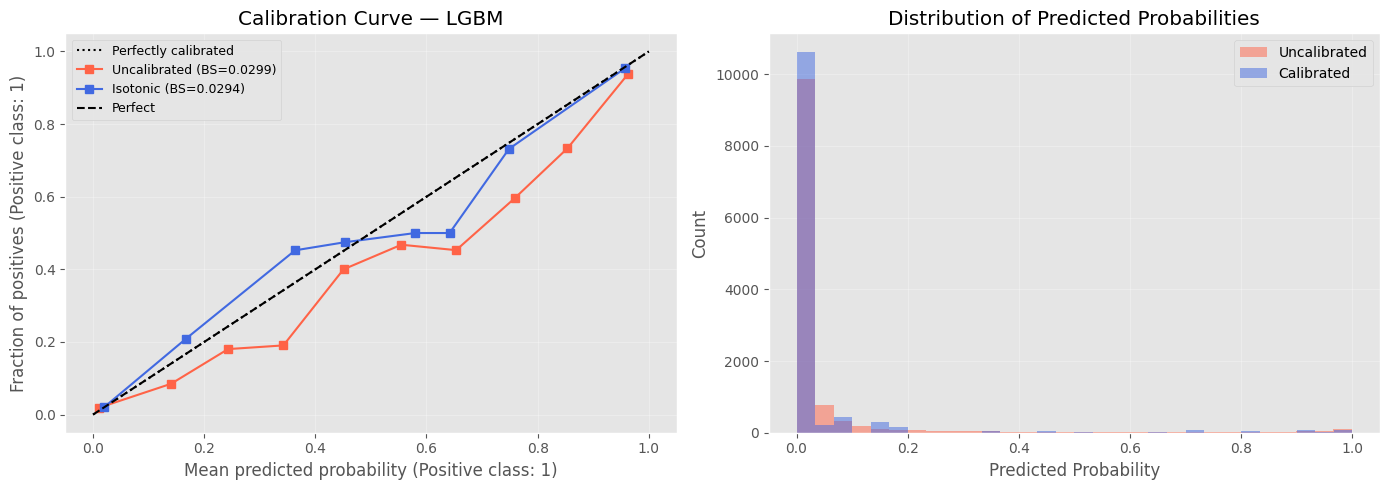

In [38]:
lgbm_res_cal, best_lgbm_cal = calibration_results(best_lgbm, X_train_enc_df, X_test_enc_df,
                                                    y_train, y_test, model_name='LGBM')

# Wrap into a single object that outputs calibrated probabilities
best_lgbm_cal = CalibratedBundle(best_lgbm_cal['model'], best_lgbm_cal['isotonic'])

In [80]:

fig15=plot_calibration_curve(best_lgbm_cal, X_test_enc_df, y_test, model_name='LGBM')
fig15.write_html("calibration_curve_lgbm_cal.html")

In [81]:
fig16=evaluate_calibration_effect(best_lgbm, best_lgbm_cal, X_test_enc_df, y_test, model_name='LightGBM')
fig16.write_html("calibration_effect_lgbm.html")


Brier Score — Uncalibrated (full train): 0.0269
Brier Score — Calibrated   (bundle):     0.0292
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0269      0.0292      0.0023              8.55%
REL (calibration)        0.0018      0.0004     -0.0014            -77.78%
RES (resolution)         0.0225      0.0190     -0.0035            -15.56%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.0205      0.0041     -0.0164             -80.0%
MCE        0.2855      0.1711     -0.1144            -40.07%


In [68]:
lgbm_res_cal=metrics_calculator(best_lgbm_cal, X_test_enc_df, y_test, 'LightGBM calib')
lgbm_res_cal

,LightGBM calib
Accuracy,96.46%
Precision,82.46%
Recall,38.21%
F1-score,52.22%
ROC-AUC,88.2%
PR-AUC,57.88%
Brier Score,0.0292
REL (calibration),0.0004
RES (resolution),0.019
UNC (uncertainty),0.0481


In [69]:
model_results = pd.concat([model_results, lgbm_results, lgbm_res_cal], axis=1)

In [70]:
model_results

,Logistic Regression,Logistic Regression calib,Decision Tree,Decision Tree calib,Random Forest,Random Forest calib,XGBoost,XGBoost calib,LightGBM,LightGBM calib
Accuracy,94.85%,94.87%,95.04%,94.93%,94.93%,94.94%,95.9%,95.64%,96.72%,96.46%
Precision,18.75%,36.0%,62.26%,50.0%,0.0%,51.22%,76.71%,75.9%,90.04%,82.46%
Recall,0.49%,1.46%,5.37%,1.95%,0.0%,3.41%,27.32%,20.49%,39.67%,38.21%
F1-score,0.95%,2.81%,9.88%,3.76%,0.0%,6.4%,40.29%,32.27%,55.08%,52.22%
ROC-AUC,73.22%,72.93%,73.34%,71.85%,76.53%,75.41%,87.89%,85.83%,90.39%,88.2%
PR-AUC,15.4%,14.02%,20.17%,16.37%,18.08%,15.91%,51.26%,43.22%,68.22%,57.88%
Brier Score,0.0459,0.046,0.0444,0.045,0.0457,0.0454,0.0334,0.0353,0.0269,0.0292
REL (calibration),0.0004,0.0004,0.0004,0.0002,0.0005,0.0003,0.0006,0.0003,0.0018,0.0004
RES (resolution),0.0023,0.0023,0.0039,0.0031,0.0019,0.0023,0.0149,0.0125,0.0225,0.019
UNC (uncertainty),0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481


## mlp

In [75]:
# # # calling the model constructor for multi layer perceptron
# from sklearn.neural_network import MLPClassifier
# mlp_base = MLPClassifier(random_state=42, max_iter=200)

# # defining a hyper parameter grid
# param_grid_mlp = {
#     "hidden_layer_sizes": [(64,), (128,), (64, 32)],
#     "activation":         ["relu"],
#     "alpha":              [0.001, 0.01],
#     "learning_rate_init": [0.001, 0.01],
# }

# best_mlp, best_mlp_hyperparams = tune_clf_hyperparameters(mlp_base, param_grid_mlp, X_train_enc_df, y_train, scoring='neg_brier_score')
# print('MLP Optimal Hyperparameters: \n', best_mlp_hyperparams)

# model_evaluation(best_mlp, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='MLP')

# mlp_rsults = metrics_calculator(best_mlp, X_test_enc_df, y_test, 'MLP')
# mlp_rsults


# 	  Classification report for training set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       1.00      1.00      1.00     46083
#            1       0.99      0.96      0.98      2458

#     accuracy                           1.00     48541
#    macro avg       1.00      0.98      0.99     48541
# weighted avg       1.00      1.00      1.00     48541


# 	   Classification report for test set
# -------------------------------------------------------
#               precision    recall  f1-score   support

#            0       0.97      0.99      0.98     11521
#            1       0.64      0.38      0.48       615

#     accuracy                           0.96     12136
#    macro avg       0.80      0.69      0.73     12136
# weighted avg       0.95      0.96      0.95     12136

# 	MLP
# Accuracy	95.76%
# Precision	63.51%
# Recall	38.21%
# F1-score	47.72%
# ROC-AUC	87.17%
# PR-AUC	47.87%
# Brier Score	0.0367
# REL (calibration)	0.002
# RES (resolution)	0.0134
# UNC (uncertainty)	0.0481
# ECE	0.0282
# MCE	0.3214


# les use optuna 



# def objective_mlp(trial):
#     n_layers = trial.suggest_int('n_layers', 1, 3)
#     layer_size = trial.suggest_int('layer_size', 32, 256, step=32)
#     hidden_layer_sizes = tuple([layer_size] * n_layers)

#     params = {
#         'hidden_layer_sizes': hidden_layer_sizes,
#         'activation':         trial.suggest_categorical('activation', ['relu', 'tanh']),
#         'alpha':              trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
#         'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
#         'batch_size':         trial.suggest_categorical('batch_size', [64, 128, 256]),
#     }

#     model = MLPClassifier(
#         **params,
#         max_iter=300,
#         early_stopping=True,
#         validation_fraction=0.1,
#         random_state=42,
#     )

#     cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#     scores = cross_val_score(model, X_train_enc_df, y_train,
#                              cv=cv, scoring='neg_brier_score', n_jobs=-1)
#     return scores.mean()

# study_mlp = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_mlp.optimize(objective_mlp, n_trials=30, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_mlp.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_mlp.best_params}")

# # Reconstruct hidden_layer_sizes from stored params
# best_mlp_params = study_mlp.best_params.copy()
# n_layers   = best_mlp_params.pop('n_layers')
# layer_size = best_mlp_params.pop('layer_size')
# best_mlp_params['hidden_layer_sizes'] = tuple([layer_size] * n_layers)

# best_mlp = MLPClassifier(**best_mlp_params, max_iter=500, random_state=42)
# best_mlp.fit(X_train_enc_df, y_train)

# model_evaluation(best_mlp, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='MLP')



#caling the classifier with the best hyperparameter
# Best Brier Score: 0.0396
# Best hyperparameters:
# {'n_layers': 1, 'layer_size': 192, 'activation': 'tanh', 'alpha': 0.000521607283003116, 'learning_rate_init': 0.0026756802806566808, 'batch_size': 256}

best_mlp = MLPClassifier(
    hidden_layer_sizes=(192,),
    activation='tanh',
    alpha=0.000521607283003116,
    learning_rate_init=0.0026756802806566808,
    batch_size=256,
    max_iter=500,
    random_state=42,
)

best_mlp.fit(X_train_enc_df, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(192,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.000521607283003116
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.0026756802806566808
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0003
         0.0       1.00      1.00      1.00     46083         ROC-AUC            1.0000
         1.0       1.00      1.00      1.00      2458         PR-AUC             0.9999
                                                              ECE                0.0009
    accuracy                           1.00     48541       
   macro avg       1.00      1.00      1.00     48541       
weighted avg       1.00      1.00      1.00     48541       

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
     

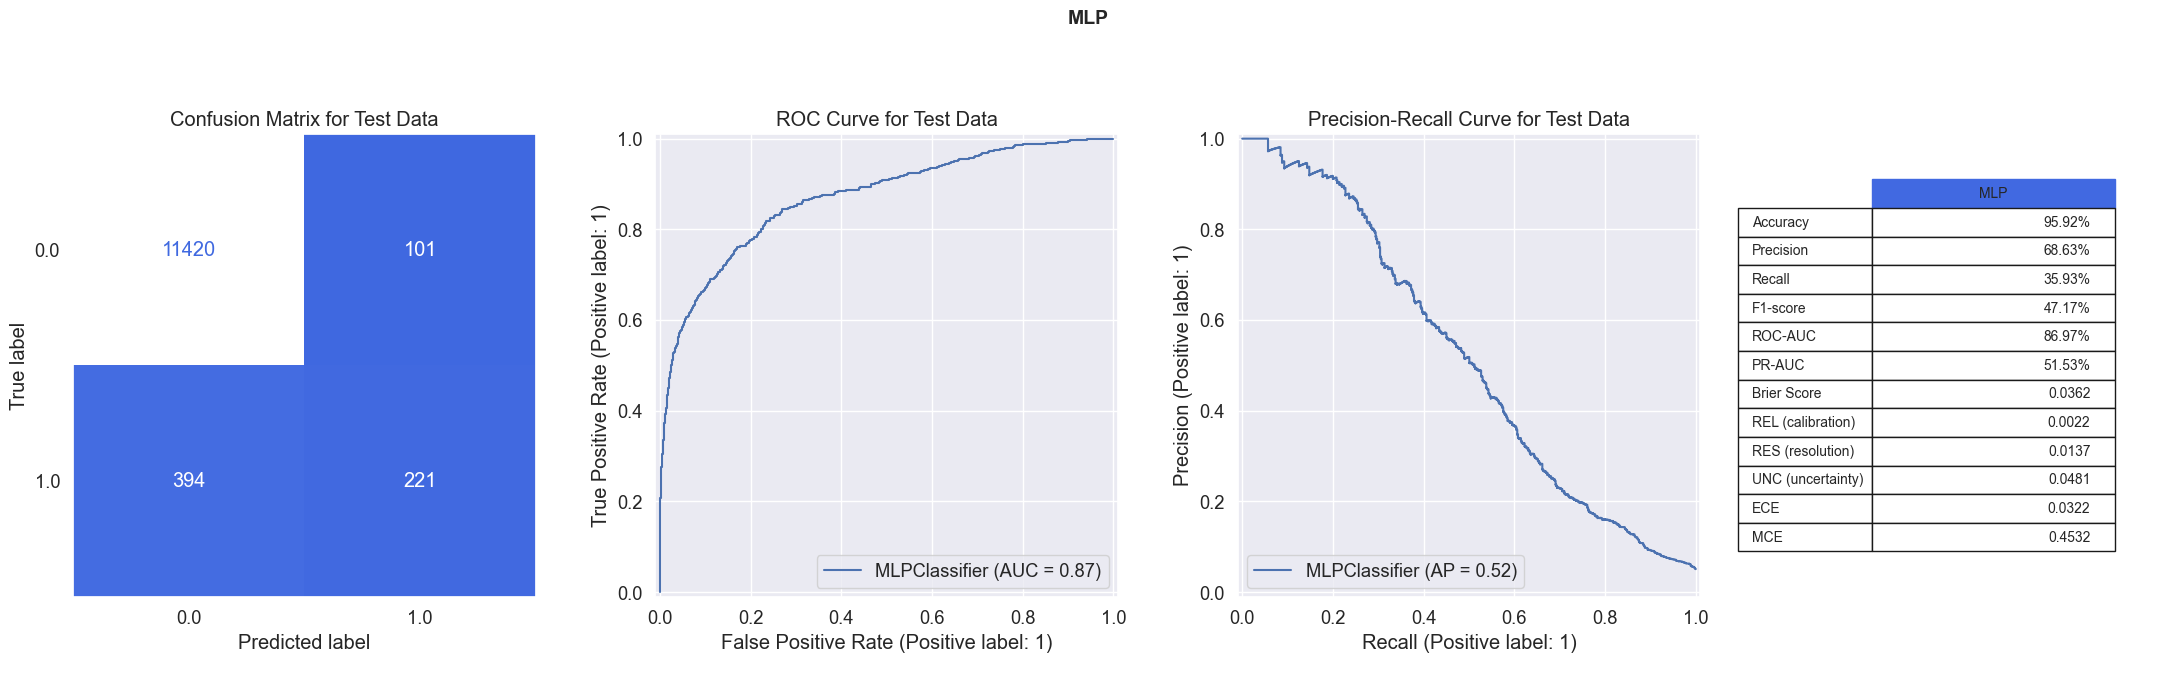

In [85]:
model_evaluation(best_mlp, X_train_enc_df, X_test_enc_df, y_train, y_test, model_name='MLP')

In [83]:
mlp_results = metrics_calculator(best_mlp, X_test_enc_df, y_test, 'MLP')
mlp_results

,MLP
Accuracy,95.92%
Precision,68.63%
Recall,35.93%
F1-score,47.17%
ROC-AUC,86.97%
PR-AUC,51.53%
Brier Score,0.0362
REL (calibration),0.0022
RES (resolution),0.0137
UNC (uncertainty),0.0481


In [ ]:
plot_metrics_vs_threshold_interactive(best_mlp, X_test_enc_df, y_test)

In [73]:
plot_calibration_curve(best_mlp, X_test_enc_df, y_test, model_name='MLP')

Brier Score — Uncalibrated: 0.0377
Brier Score — Calibrated:   0.0349
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0377               0.0349     -0.0028             -7.43%
REL (calibration)        0.0029               0.0003     -0.0026            -89.66%
RES (resolution)         0.0130               0.0132      0.0002              1.54%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0339               0.0058     -0.0281            -82.89%
MCE        0.3781               0.4866      0.1085              28.7%


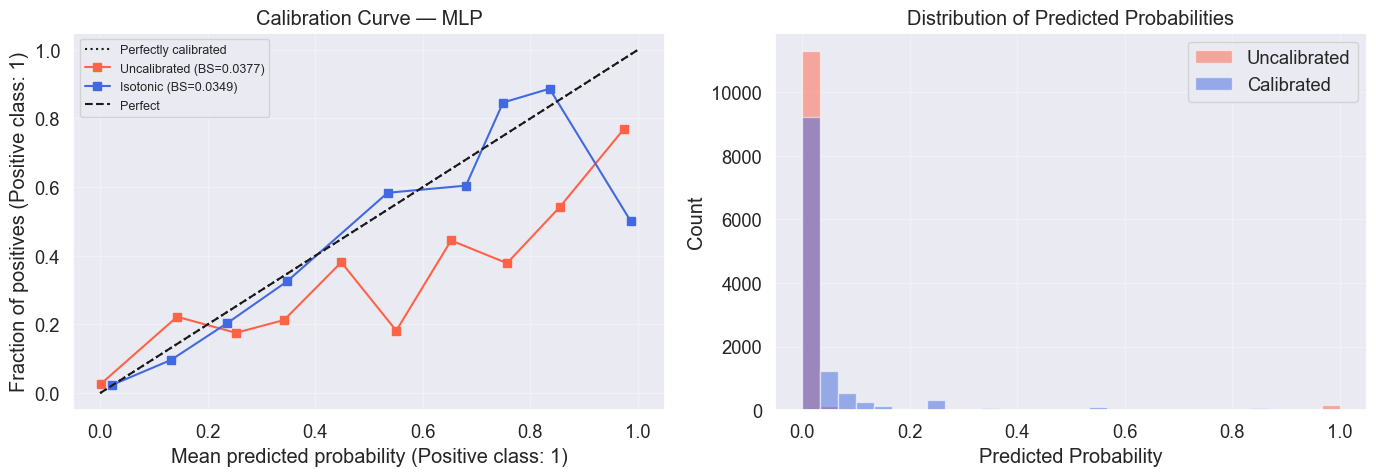

In [87]:
mlp_res_cal, best_mlp_cal = calibration_results(best_mlp, X_train_enc_df, X_test_enc_df,
                                                    y_train, y_test, model_name='MLP')

# Wrap into a single object that outputs calibrated probabilities
best_mlp_cal = CalibratedBundle(best_mlp_cal['model'], best_mlp_cal['isotonic'])

In [88]:
evaluate_calibration_effect(best_mlp, best_mlp_cal, X_test_enc_df, y_test, model_name='MLP')

Brier Score — Uncalibrated (full train): 0.0362
Brier Score — Calibrated   (bundle):     0.0349
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0362      0.0349     -0.0013             -3.59%
REL (calibration)        0.0022      0.0003     -0.0019            -86.36%
RES (resolution)         0.0137      0.0132     -0.0005             -3.65%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.0322      0.0058     -0.0264            -81.99%
MCE        0.4532      0.4866      0.0334              7.37%


In [76]:
mlp_res_cal=metrics_calculator(best_mlp_cal, X_test_enc_df, y_test, 'MLP calib')
mlp_res_cal

,MLP calib
Accuracy,95.94%
Precision,69.06%
Recall,35.93%
F1-score,47.27%
ROC-AUC,84.39%
PR-AUC,44.12%
Brier Score,0.0349
REL (calibration),0.0003
RES (resolution),0.0132
UNC (uncertainty),0.0481


In [77]:
model_results = pd.concat([model_results, mlp_results, mlp_res_cal], axis=1)

In [78]:
model_results

,Logistic Regression,Logistic Regression calib,Decision Tree,Decision Tree calib,Random Forest,Random Forest calib,XGBoost,XGBoost calib,LightGBM,LightGBM calib,MLP,MLP calib
Accuracy,94.85%,94.87%,95.04%,94.93%,94.93%,94.94%,95.9%,95.64%,96.72%,96.46%,95.92%,95.94%
Precision,18.75%,36.0%,62.26%,50.0%,0.0%,51.22%,76.71%,75.9%,90.04%,82.46%,68.63%,69.06%
Recall,0.49%,1.46%,5.37%,1.95%,0.0%,3.41%,27.32%,20.49%,39.67%,38.21%,35.93%,35.93%
F1-score,0.95%,2.81%,9.88%,3.76%,0.0%,6.4%,40.29%,32.27%,55.08%,52.22%,47.17%,47.27%
ROC-AUC,73.22%,72.93%,73.34%,71.85%,76.53%,75.41%,87.89%,85.83%,90.39%,88.2%,86.97%,84.39%
PR-AUC,15.4%,14.02%,20.17%,16.37%,18.08%,15.91%,51.26%,43.22%,68.22%,57.88%,51.53%,44.12%
Brier Score,0.0459,0.046,0.0444,0.045,0.0457,0.0454,0.0334,0.0353,0.0269,0.0292,0.0362,0.0349
REL (calibration),0.0004,0.0004,0.0004,0.0002,0.0005,0.0003,0.0006,0.0003,0.0018,0.0004,0.0022,0.0003
RES (resolution),0.0023,0.0023,0.0039,0.0031,0.0019,0.0023,0.0149,0.0125,0.0225,0.019,0.0137,0.0132
UNC (uncertainty),0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481


# getting the SHAP values for the light gbm and use the elbow method to select the best features

C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


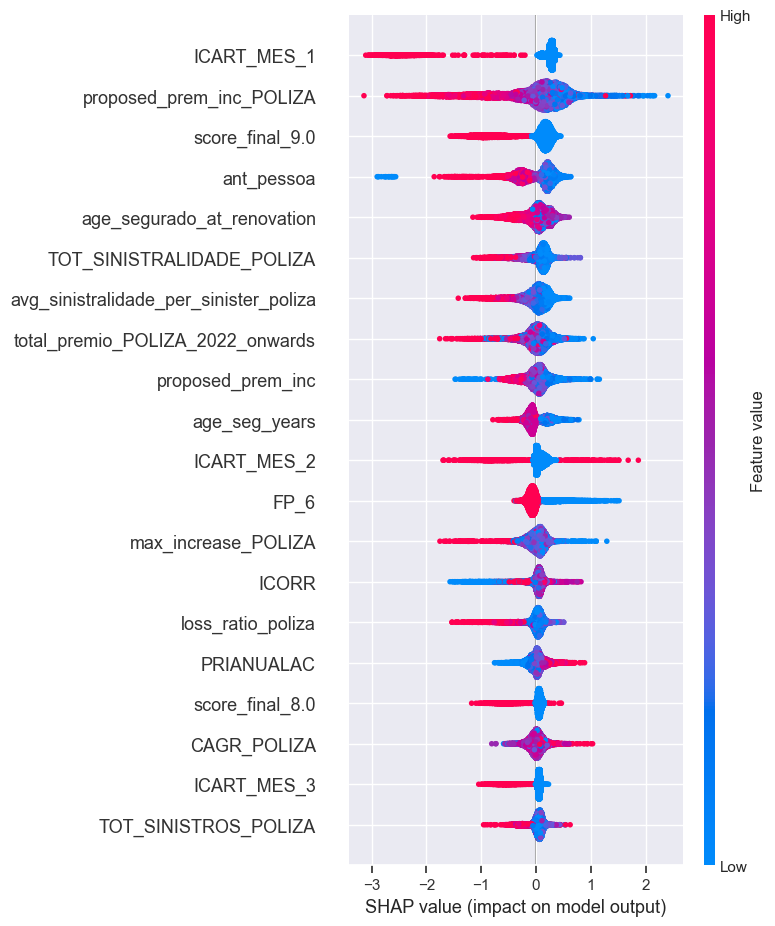

In [79]:
explainer = shap.TreeExplainer(best_lgbm)
SHAP_values_test = explainer.shap_values(X_test_enc_df)
shap.summary_plot(SHAP_values_test, X_test_enc_df, max_display=20)

C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


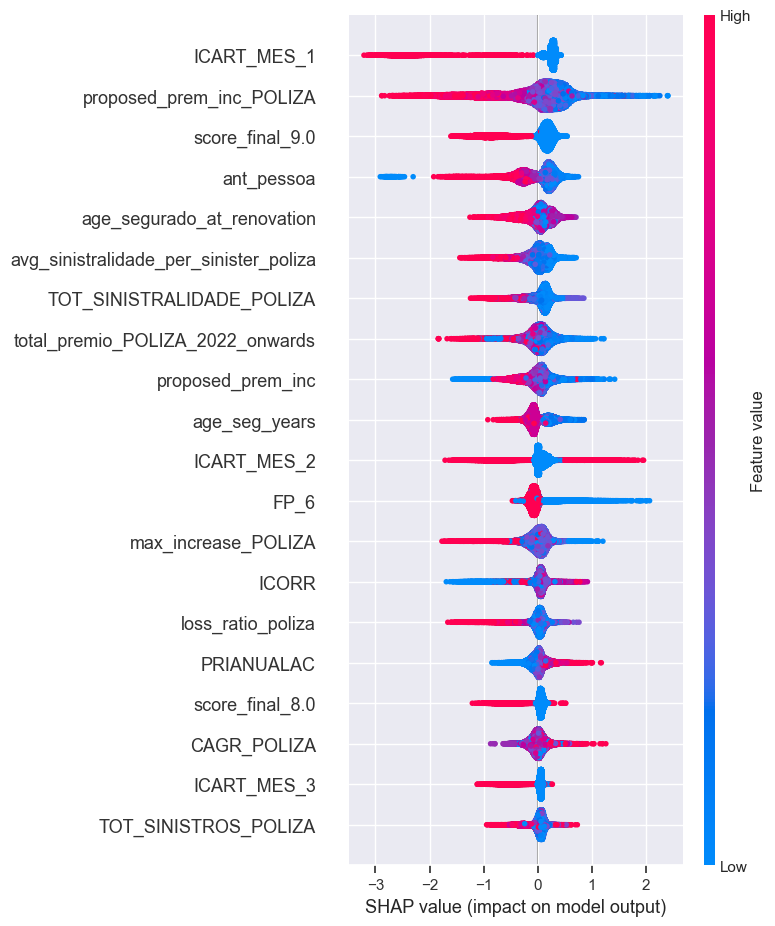

In [80]:

SHAP_values_train = explainer.shap_values(X_train_enc_df)
shap.summary_plot(SHAP_values_train, X_train_enc_df, max_display=20)

C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


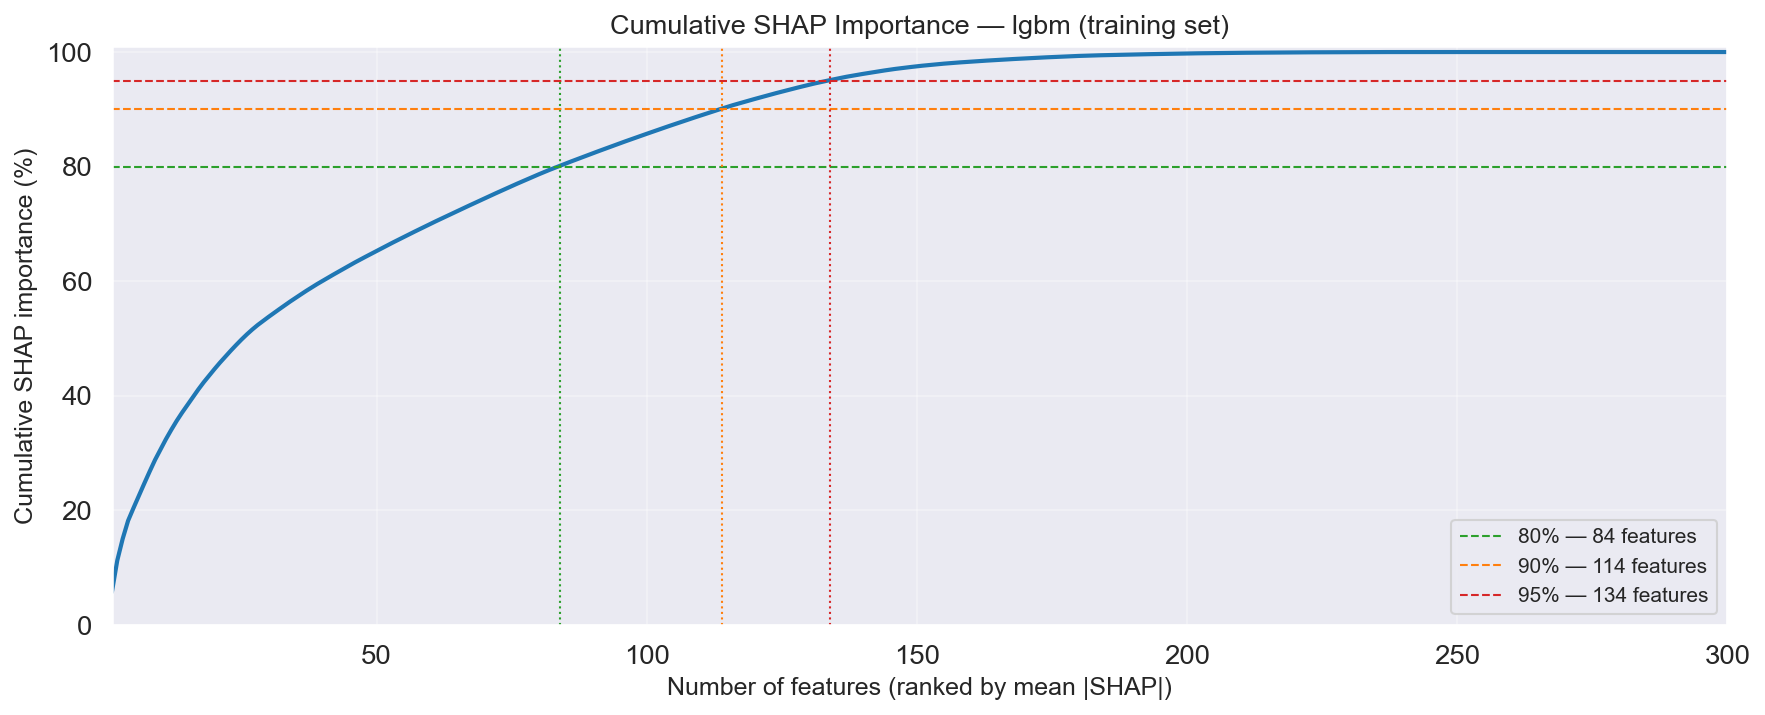

In [81]:
# ✅ Compute SHAP values on TRAINING data for feature selection
SHAP_values_train = explainer.shap_values(X_train_enc_df)
shap_train_arr = SHAP_values_train[1] if isinstance(SHAP_values_train, list) else SHAP_values_train

mean_abs_shap_train = pd.Series(
    np.abs(shap_train_arr).mean(axis=0),
    index=X_train_enc_df.columns
)
shap_sorted = mean_abs_shap_train.sort_values(ascending=False)
shap_pct = shap_sorted / shap_sorted.sum() * 100
shap_cumulative = shap_pct.cumsum()
n_features = range(1, len(shap_cumulative) + 1)

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
ax.plot(n_features, shap_cumulative.values, color="#1f77b4", linewidth=2)

for threshold, color in [(80, "#2ca02c"), (90, "#ff7f0e"), (95, "#d62728")]:
    n_at_threshold = (shap_cumulative <= threshold).sum() + 1
    ax.axhline(threshold, linestyle="--", linewidth=1, color=color,
               label=f"{threshold}% — {n_at_threshold} features")
    ax.axvline(n_at_threshold, linestyle=":", linewidth=1, color=color)

ax.set_xlabel("Number of features (ranked by mean |SHAP|)", fontsize=12)
ax.set_ylabel("Cumulative SHAP importance (%)", fontsize=12)
ax.set_title("Cumulative SHAP Importance — lgbm (training set)", fontsize=13)
ax.set_xlim(1, len(shap_cumulative))
ax.set_ylim(0, 101)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
shap_sorted_lgbm, shap_cumulative_lgbm = plot_cumulative_shap(best_lgbm, X_train_enc_df, model_name="LightGBM")

C:\Users\e982233\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [83]:

# --- 1. Select features explaining 98.2% of SHAP importance (from TRAIN) ---
features_98_2 = shap_sorted_lgbm[shap_cumulative_lgbm <= 98.2].index.tolist()
features_98_2 += [shap_sorted_lgbm.index[(shap_cumulative_lgbm <= 98.2).sum()]]

print(f"Features selected: {len(features_98_2)} / {len(shap_sorted_lgbm)}")

# --- 2. Subset train/test ---
X_train_98_2 = X_train_enc_df[features_98_2]
X_test_98_2  = X_test_enc_df[features_98_2]



Features selected: 159 / 300


In [ ]:
# optuna.logging.set_verbosity(optuna.logging.WARNING)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# def objective_lgbm(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
#         'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
#         'num_leaves':        trial.suggest_int('num_leaves', 20, 63),       # ← capped
#         'max_depth':         trial.suggest_int('max_depth', 3, 7),          # ← shallower
#         'min_child_samples': trial.suggest_int('min_child_samples', 30, 150), # ← higher floor
#         'subsample':         trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 0.9),
#         'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),  # ← no near-zero
#         'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 5.0, log=True), # ← no near-zero
#     }

#     model = LGBMClassifier(**params)
#     scores = cross_val_score(
#         model,
#         X_train_98_2,
#         y_train,
#         cv=cv,
#         scoring='neg_brier_score',
#         n_jobs=-1
#     )
#     return scores.mean()

# study_lgbm_98_2 = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_lgbm_98_2.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_lgbm_98_2.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_lgbm_98_2.best_params}")

# # Reconstruct and fit on full training set
# best_lgbm_98_2 = LGBMClassifier(
#     **study_lgbm_98_2.best_params,
#     scale_pos_weight=scale_pos,
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1
# )
# best_lgbm_98_2.fit(X_train_98_2, y_train)
# Best Brier Score: 0.0322
# Best hyperparameters:
# {'n_estimators': 499, 'learning_rate': 0.06688236523419346, 'num_leaves': 32, 'max_depth': 7, 'min_child_samples': 98, 'subsample': 0.8108097698273996, 'colsample_bytree': 0.5044089573993916, 'reg_alpha': 0.3526104284733903, 'reg_lambda': 0.39530871181473587}

# calling the model constructor with the best hyper parameters from the optuna study
best_lgbm_98_2 = LGBMClassifier(
    n_estimators=499,
    learning_rate=0.06688236523419346,
    num_leaves=32,
    max_depth=7,
    min_child_samples=98,
    subsample=0.8108097698273996,
    colsample_bytree=0.5044089573993916,
    reg_alpha=0.3526104284733903,
    reg_lambda=0.39530871181473587,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
best_lgbm_98_2.fit(X_train_98_2, y_train)

Best trial: 11. Best value: -0.0322431: 100%|██████████| 20/20 [04:58<00:00, 14.92s/it]



Best Brier Score: 0.0322
Best hyperparameters:
{'n_estimators': 499, 'learning_rate': 0.06688236523419346, 'num_leaves': 32, 'max_depth': 7, 'min_child_samples': 98, 'subsample': 0.8108097698273996, 'colsample_bytree': 0.5044089573993916, 'reg_alpha': 0.3526104284733903, 'reg_lambda': 0.39530871181473587}


,boosting_type,'gbdt'
,num_leaves,32
,max_depth,7
,learning_rate,0.06688236523419346
,n_estimators,499
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,98


	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0361
         0.0       1.00      0.96      0.98     46083         ROC-AUC            0.9978
         1.0       0.59      1.00      0.74      2458         PR-AUC             0.9525
                                                              ECE                0.1063
    accuracy                           0.96     48541       
   macro avg       0.79      0.98      0.86     48541       
weighted avg       0.98      0.96      0.97     48541       

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
     

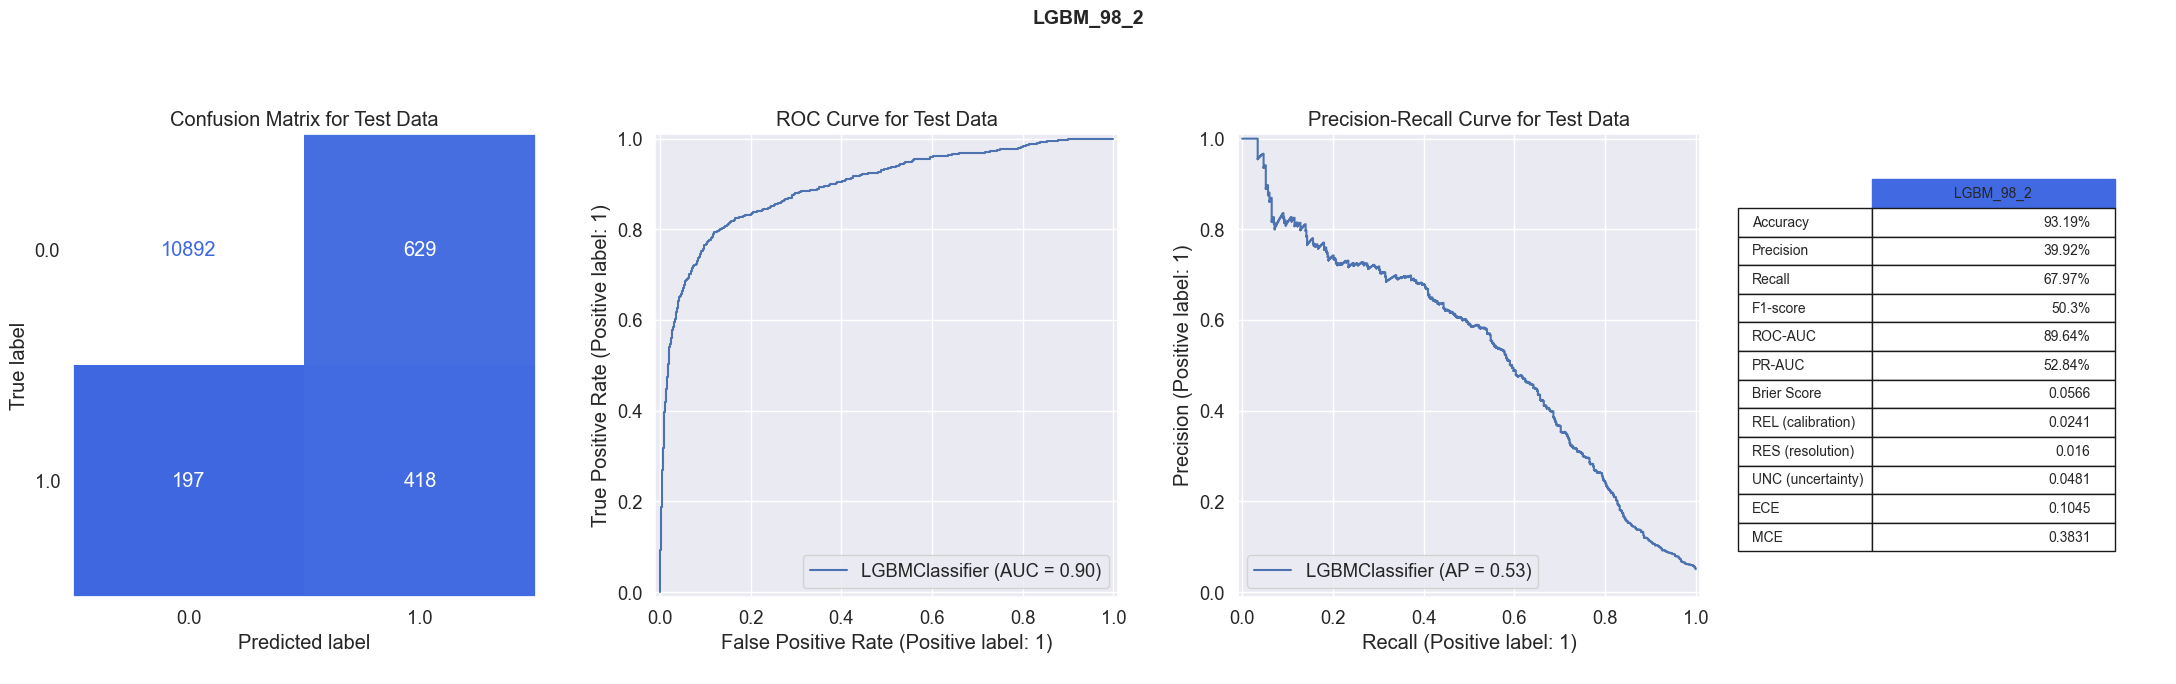

In [85]:
model_evaluation(best_lgbm_98_2, X_train_98_2, X_test_98_2, y_train, y_test, model_name='LGBM_98_2')

In [86]:
lightGBM_98_2_results = metrics_calculator(best_lgbm_98_2, X_test_98_2, y_test, 'LightGBM 98.2% SHAP')
lightGBM_98_2_results

,LightGBM 98.2% SHAP
Accuracy,93.19%
Precision,39.92%
Recall,67.97%
F1-score,50.3%
ROC-AUC,89.64%
PR-AUC,52.84%
Brier Score,0.0566
REL (calibration),0.0241
RES (resolution),0.016
UNC (uncertainty),0.0481


In [87]:
plot_calibration_curve(best_lgbm_98_2, X_test_98_2, y_test, model_name='LGBM_98_2')

Brier Score — Uncalibrated: 0.0548
Brier Score — Calibrated:   0.0340
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0548               0.0340     -0.0208            -37.96%
REL (calibration)        0.0207               0.0002     -0.0205            -99.03%
RES (resolution)         0.0143               0.0140     -0.0003              -2.1%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.0915               0.0035     -0.0880            -96.17%
MCE        0.3731               0.1353     -0.2378            -63.74%


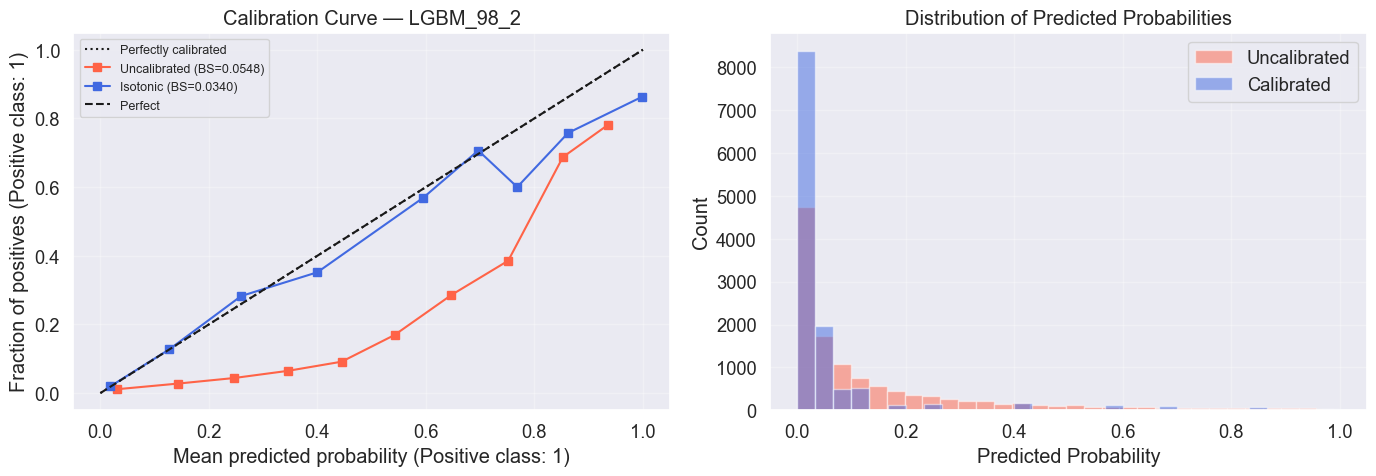

In [88]:
#lets calibrate this mf

lgbm_98_2_res_cal, best_lgbm_98_2_cal = calibration_results(best_lgbm_98_2, X_train_98_2, X_test_98_2,
                                                    y_train, y_test, model_name='LGBM_98_2')

In [89]:
#constructing the calibrated models
best_lgbm_98_2_cal = CalibratedBundle(best_lgbm_98_2_cal['model'], best_lgbm_98_2_cal['isotonic'])

In [90]:
# calculate the results
lgbm_98_2_res_cal=metrics_calculator(best_lgbm_98_2_cal, X_test_98_2, y_test, 'LightGBM 98.2% SHAP calib')
lgbm_98_2_res_full = pd.concat([lightGBM_98_2_results, lgbm_98_2_res_cal], axis=1)
lgbm_98_2_res_full

,LightGBM 98.2% SHAP,LightGBM 98.2% SHAP calib
Accuracy,93.19%,95.9%
Precision,39.92%,67.77%
Recall,67.97%,36.59%
F1-score,50.3%,47.52%
ROC-AUC,89.64%,87.02%
PR-AUC,52.84%,45.58%
Brier Score,0.0566,0.034
REL (calibration),0.0241,0.0002
RES (resolution),0.016,0.014
UNC (uncertainty),0.0481,0.0481


In [91]:
evaluate_calibration_effect(best_lgbm_98_2, best_lgbm_98_2_cal, X_test_98_2, y_test, model_name='LGBM_98_2')

Brier Score — Uncalibrated (full train): 0.0566
Brier Score — Calibrated   (bundle):     0.0340
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0566      0.0340     -0.0226            -39.93%
REL (calibration)        0.0241      0.0002     -0.0239            -99.17%
RES (resolution)         0.0160      0.0140     -0.0020             -12.5%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.1045      0.0035     -0.1010            -96.65%
MCE        0.3831      0.1353     -0.2478            -64.68%


In [92]:
# --- 1. Select features explaining 90% of SHAP importance (from TRAIN) ---
features_90 = shap_sorted_lgbm[shap_cumulative_lgbm <= 90].index.tolist()
features_90 += [shap_sorted_lgbm.index[(shap_cumulative_lgbm <= 90).sum()]]

print(f"Features selected: {len(features_90)} / {len(shap_sorted_lgbm)}")

# --- 2. Subset train/test ---
X_train_90 = X_train_enc_df[features_90]
X_test_90  = X_test_enc_df[features_90]


Features selected: 114 / 300


In [ ]:


# optuna.logging.set_verbosity(optuna.logging.WARNING)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# def objective_lgbm(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
#         'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
#         'num_leaves':        trial.suggest_int('num_leaves', 20, 63),       # ← capped
#         'max_depth':         trial.suggest_int('max_depth', 3, 7),          # ← shallower
#         'min_child_samples': trial.suggest_int('min_child_samples', 30, 150), # ← higher floor
#         'subsample':         trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 0.9),
#         'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),  # ← no near-zero
#         'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 5.0, log=True), # ← no near-zero
#     }

#     model = LGBMClassifier(**params)
#     scores = cross_val_score(
#         model,
#         X_train_90,
#         y_train,
#         cv=cv,
#         scoring='neg_brier_score',
#         n_jobs=-1
#     )
#     return scores.mean()

# study_lgbm_90 = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_lgbm_90.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_lgbm_90.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_lgbm_90.best_params}")

# # Reconstruct and fit on full training set
# best_lgbm_90 = LGBMClassifier(
#     **study_lgbm_90.best_params,
#     scale_pos_weight=scale_pos,
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1
# )
# best_lgbm_90.fit(X_train_90, y_train)

# Best Brier Score: 0.0346
# Best hyperparameters:
# {'n_estimators': 300, 'learning_rate': 0.06688236523419346, 'num_leaves': 32, 'max_depth': 7, 'min_child_samples': 98, 'subsample': 0.8108097698273996, 'colsample_bytree': 0.5044089573993916, 'reg_alpha': 0.3526104284733903, 'reg_lambda': 0.39530871181473587}

#calling the model constructor with the best hyper parameters from the optuna study
best_lgbm_90 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.06688236523419346,
    num_leaves=32,
    max_depth=7,
    min_child_samples=98,
    subsample=0.8108097698273996,
    colsample_bytree=0.5044089573993916,
    reg_alpha=0.3526104284733903,
    reg_lambda=0.39530871181473587,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
best_lgbm_90.fit(X_train_90, y_train)

Best trial: 11. Best value: -0.0346499: 100%|██████████| 20/20 [02:49<00:00,  8.47s/it]



Best Brier Score: 0.0346
Best hyperparameters:
{'n_estimators': 300, 'learning_rate': 0.06688236523419346, 'num_leaves': 32, 'max_depth': 7, 'min_child_samples': 98, 'subsample': 0.8108097698273996, 'colsample_bytree': 0.5044089573993916, 'reg_alpha': 0.3526104284733903, 'reg_lambda': 0.39530871181473587}


,boosting_type,'gbdt'
,num_leaves,32
,max_depth,7
,learning_rate,0.06688236523419346
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,98


	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0658
         0.0       1.00      0.92      0.96     46083         ROC-AUC            0.9898
         1.0       0.40      0.99      0.56      2458         PR-AUC             0.8350
                                                              ECE                0.1609
    accuracy                           0.92     48541       
   macro avg       0.70      0.95      0.76     48541       
weighted avg       0.97      0.92      0.94     48541       

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
     

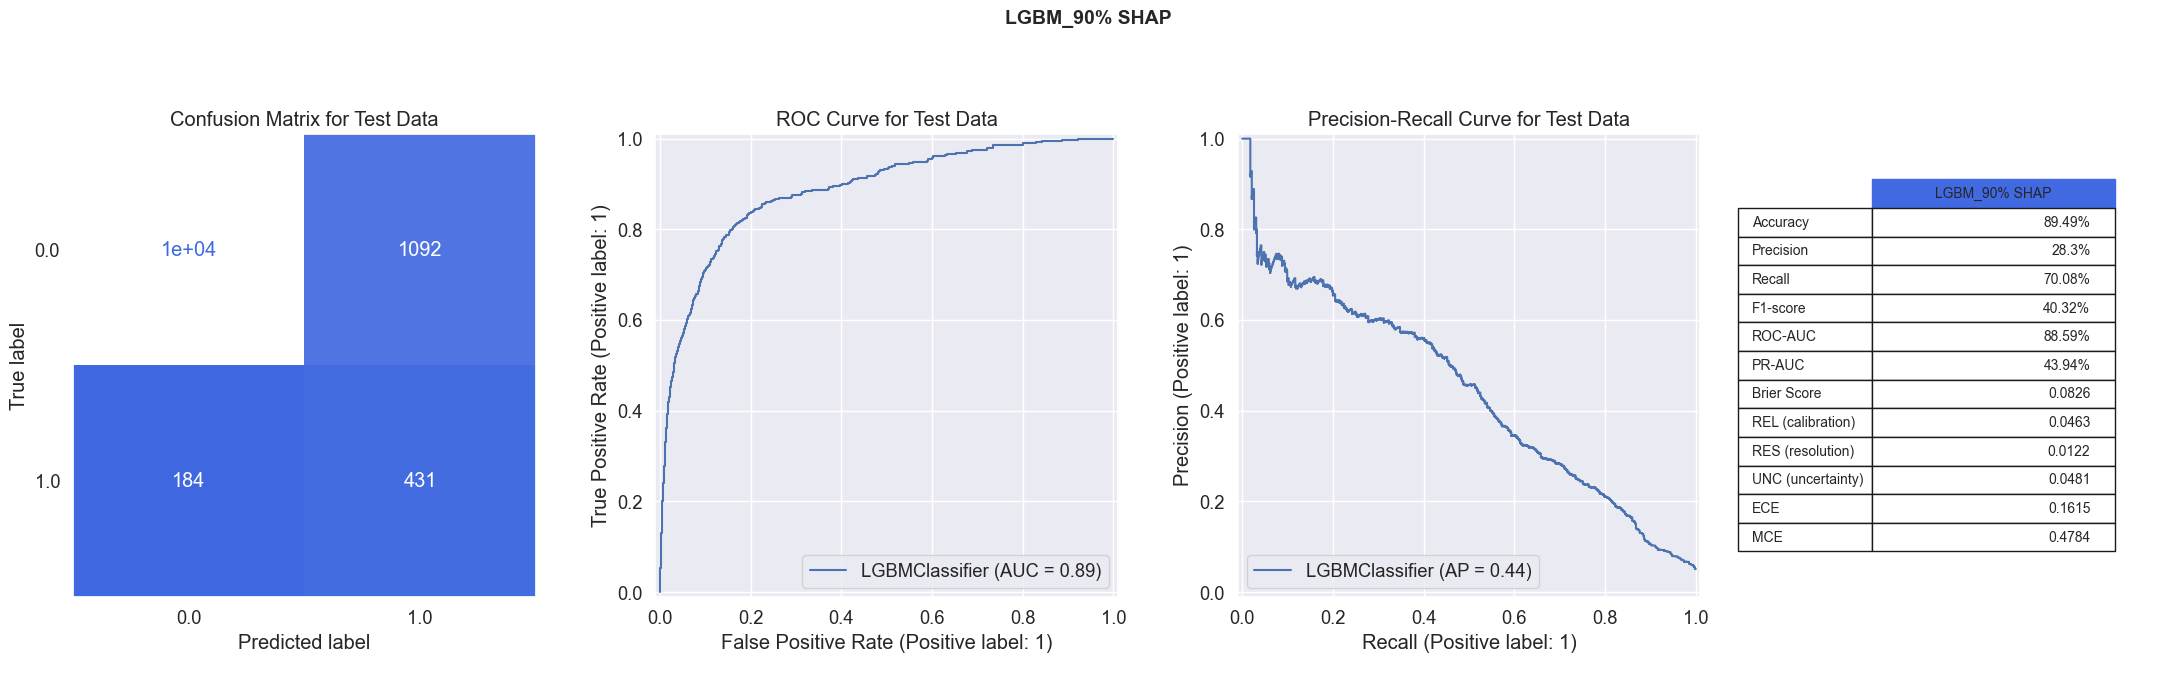

In [94]:
model_evaluation(best_lgbm_90, X_train_90, X_test_90, y_train, y_test, model_name='LGBM_90% SHAP')

In [95]:
plot_calibration_curve(best_lgbm_90, X_test_90, y_test, model_name='LGBM_90% SHAP')

Brier Score — Uncalibrated: 0.0785
Brier Score — Calibrated:   0.0374
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0785               0.0374     -0.0411            -52.36%
REL (calibration)        0.0412               0.0005     -0.0407            -98.79%
RES (resolution)         0.0114               0.0110     -0.0004             -3.51%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.1485               0.0058     -0.1427            -96.09%
MCE        0.4374               0.1857     -0.2517            -57.54%


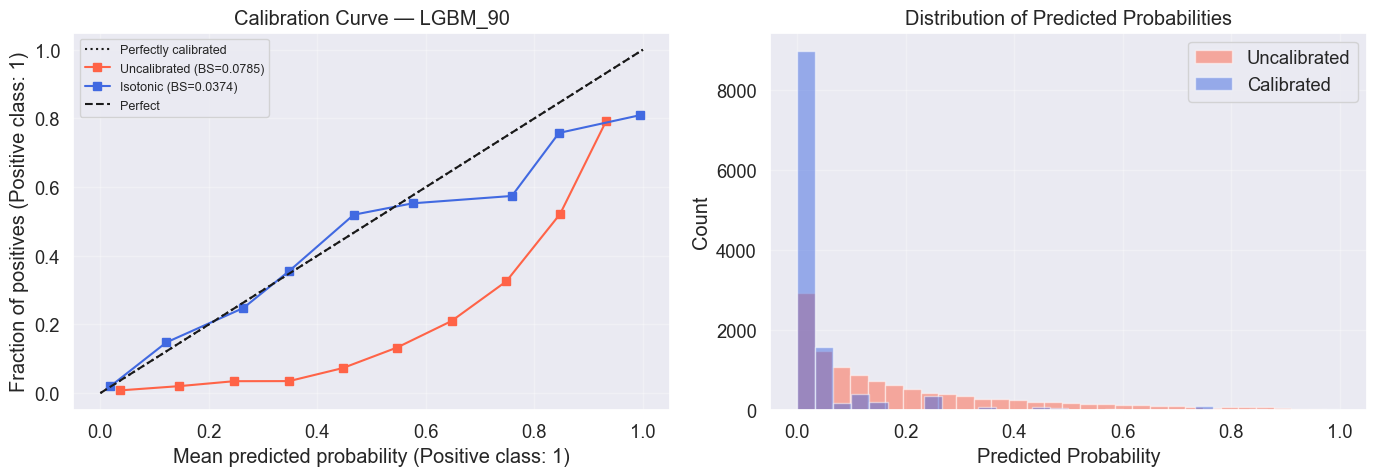

In [96]:
# lets calibrate thsi mf

lgbm_90_res_cal, best_lgbm_90_cal = calibration_results(best_lgbm_90, X_train_90, X_test_90,
                                                    y_train, y_test, model_name='LGBM_90')

In [98]:
best_lgbm_90_cal=CalibratedBundle(best_lgbm_90_cal['model'], best_lgbm_90_cal['isotonic'])

In [99]:
evaluate_calibration_effect(best_lgbm_90, best_lgbm_90_cal, X_test_90, y_test, model_name='LGBM_90% SHAP')

Brier Score — Uncalibrated (full train): 0.0826
Brier Score — Calibrated   (bundle):     0.0374
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0826      0.0374     -0.0452            -54.72%
REL (calibration)        0.0463      0.0005     -0.0458            -98.92%
RES (resolution)         0.0122      0.0110     -0.0012             -9.84%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.1615      0.0058     -0.1557            -96.41%
MCE        0.4784      0.1857     -0.2927            -61.18%


In [100]:
# calculate the results
lgbm_res_90= metrics_calculator(best_lgbm_90, X_test_90, y_test, 'LightGBM 90% SHAP ')
lgbm_res_90_cal=metrics_calculator(best_lgbm_90_cal, X_test_90, y_test, 'LightGBM 90% SHAP calib')
lgbm_90_res_full = pd.concat([lgbm_res_90, lgbm_res_90_cal], axis=1)
lgbm_90_res_full

,LightGBM 90% SHAP,LightGBM 90% SHAP calib
Accuracy,89.49%,95.36%
Precision,28.3%,62.38%
Recall,70.08%,21.3%
F1-score,40.32%,31.76%
ROC-AUC,88.59%,86.4%
PR-AUC,43.94%,38.19%
Brier Score,0.0826,0.0374
REL (calibration),0.0463,0.0005
RES (resolution),0.0122,0.011
UNC (uncertainty),0.0481,0.0481


In [101]:
lgbm_trunc_res = pd.concat([lgbm_98_2_res_full, lgbm_90_res_full], axis=1)
lgbm_trunc_res

,LightGBM 98.2% SHAP,LightGBM 98.2% SHAP calib,LightGBM 90% SHAP,LightGBM 90% SHAP calib
Accuracy,93.19%,95.9%,89.49%,95.36%
Precision,39.92%,67.77%,28.3%,62.38%
Recall,67.97%,36.59%,70.08%,21.3%
F1-score,50.3%,47.52%,40.32%,31.76%
ROC-AUC,89.64%,87.02%,88.59%,86.4%
PR-AUC,52.84%,45.58%,43.94%,38.19%
Brier Score,0.0566,0.034,0.0826,0.0374
REL (calibration),0.0241,0.0002,0.0463,0.0005
RES (resolution),0.016,0.014,0.0122,0.011
UNC (uncertainty),0.0481,0.0481,0.0481,0.0481


In [102]:
# now lets go for the 80% comulative SHAP

# --- 1. Select features explaining 80% of SHAP importance (from TRAIN) ---
features_80 = shap_sorted_lgbm[shap_cumulative_lgbm <= 80].index.tolist()
features_80 += [shap_sorted_lgbm.index[(shap_cumulative_lgbm <= 80).sum()]]

print(f"Features selected: {len(features_80)} / {len(shap_sorted_lgbm)}")

# --- 2. Subset train/test ---
X_train_80 = X_train_enc_df[features_80]
X_test_80  = X_test_enc_df[features_80]


Features selected: 84 / 300


In [ ]:
# optuna.logging.set_verbosity(optuna.logging.WARNING)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# def objective_lgbm(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
#         'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
#         'num_leaves':        trial.suggest_int('num_leaves', 20, 63),       # ← capped
#         'max_depth':         trial.suggest_int('max_depth', 3, 7),          # ← shallower
#         'min_child_samples': trial.suggest_int('min_child_samples', 30, 150), # ← higher floor
#         'subsample':         trial.suggest_float('subsample', 0.6, 0.9),
#         'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 0.9),
#         'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),  # ← no near-zero
#         'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 5.0, log=True), # ← no near-zero
#     }

#     model = LGBMClassifier(**params)
#     scores = cross_val_score(
#         model,
#         X_train_80,
#         y_train,
#         cv=cv,
#         scoring='neg_brier_score',
#         n_jobs=-1
#     )
#     return scores.mean()

# study_lgbm_80 = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study_lgbm_80.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)

# print(f"\nBest Brier Score: {-study_lgbm_80.best_value:.4f}")
# print(f"Best hyperparameters:\n{study_lgbm_80.best_params}")

# # Reconstruct and fit on full training set
# best_lgbm_80 = LGBMClassifier(
#     **study_lgbm_80.best_params,
#     scale_pos_weight=scale_pos,
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1
# )
# best_lgbm_80.fit(X_train_80, y_train)

# Best Brier Score: 0.0347
# Best hyperparameters:
# {'n_estimators': 300, 'learning_rate': 0.06688236523419346, 'num_leaves': 32, 'max_depth': 7, 'min_child_samples': 98, 'subsample': 0.8108097698273996, 'colsample_bytree': 0.5044089573993916, 'reg_alpha': 0.3526104284733903, 'reg_lambda': 0.39530871181473587}


#calling the model constructor with the best hyper parameters from the optuna study
best_lgbm_80 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.06688236523419346,
    num_leaves=32,
    max_depth=7,
    min_child_samples=98,
    subsample=0.8108097698273996,
    colsample_bytree=0.5044089573993916,
    reg_alpha=0.3526104284733903,
    reg_lambda=0.39530871181473587,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
best_lgbm_80.fit(X_train_80, y_train)

Best trial: 11. Best value: -0.0347379: 100%|██████████| 20/20 [02:48<00:00,  8.40s/it]



Best Brier Score: 0.0347
Best hyperparameters:
{'n_estimators': 300, 'learning_rate': 0.06688236523419346, 'num_leaves': 32, 'max_depth': 7, 'min_child_samples': 98, 'subsample': 0.8108097698273996, 'colsample_bytree': 0.5044089573993916, 'reg_alpha': 0.3526104284733903, 'reg_lambda': 0.39530871181473587}


,boosting_type,'gbdt'
,num_leaves,32
,max_depth,7
,learning_rate,0.06688236523419346
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,98


	 Classification report — TRAIN                             	 Probability Metrics — TRAIN
-------------------------------------------------------     -----------------------------------
              precision    recall  f1-score   support         Train Probability Metrics
                                                              Brier Score        0.0669
         0.0       1.00      0.92      0.96     46083         ROC-AUC            0.9894
         1.0       0.39      0.99      0.56      2458         PR-AUC             0.8284
                                                              ECE                0.1637
    accuracy                           0.92     48541       
   macro avg       0.70      0.95      0.76     48541       
weighted avg       0.97      0.92      0.94     48541       

	 Classification report — TEST                              	 Probability Metrics — TEST
-------------------------------------------------------     -----------------------------------
     

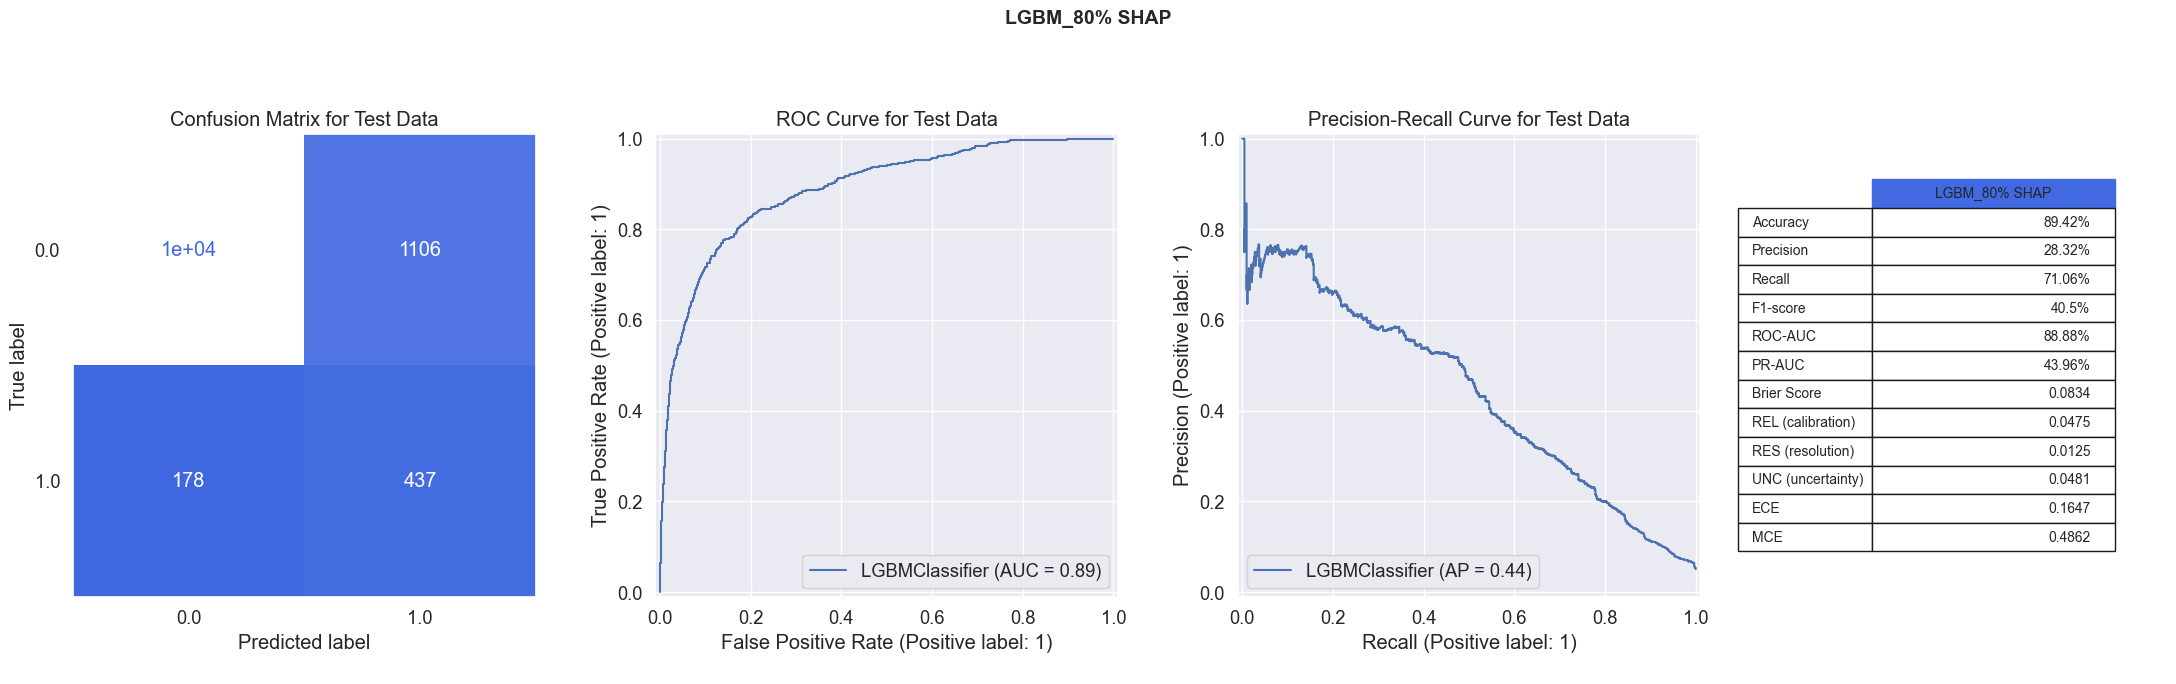

In [104]:
# evaluate th model 
model_evaluation(best_lgbm_80, X_train_80, X_test_80, y_train, y_test, model_name='LGBM_80% SHAP')

In [105]:
plot_calibration_curve(best_lgbm_80, X_test_80, y_test, model_name='LGBM_80% SHAP')

Brier Score — Uncalibrated: 0.0786
Brier Score — Calibrated:   0.0373
                   Uncalibrated  Isotonic Calibrated  Difference Difference percent
Brier Score              0.0786               0.0373     -0.0413            -52.54%
REL (calibration)        0.0411               0.0004     -0.0407            -99.03%
RES (resolution)         0.0112               0.0109     -0.0003             -2.68%
UNC (uncertainty)        0.0481               0.0481      0.0000               0.0%
     Uncalibrated  Isotonic Calibrated  Difference Difference percent
ECE        0.1516               0.0059     -0.1457            -96.11%
MCE        0.4324               0.2411     -0.1913            -44.24%


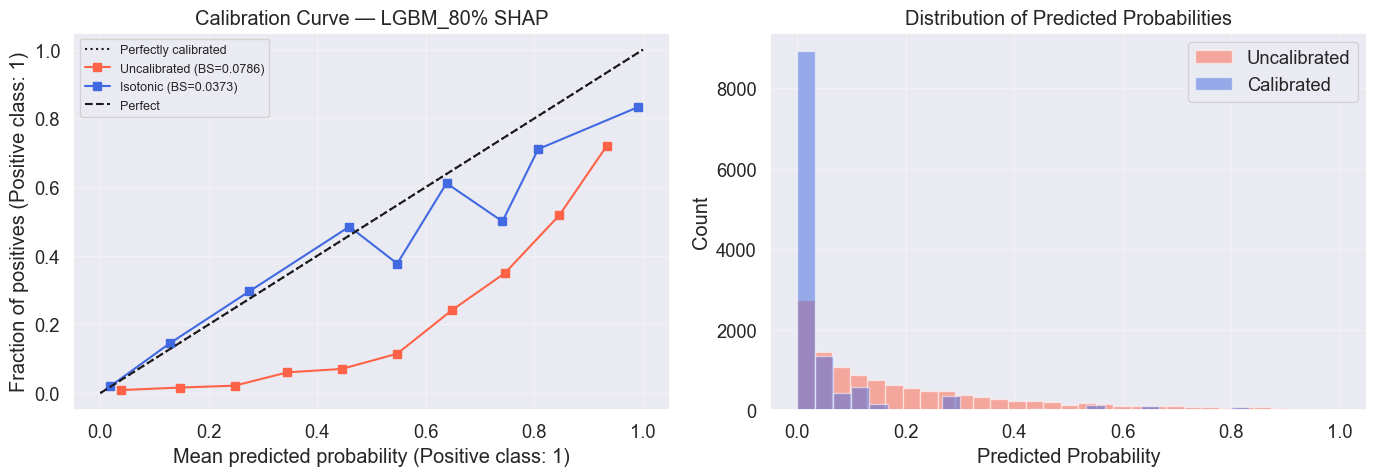

In [106]:
lgbm_80_res_cal, best_lgbm_80_cal = calibration_results(best_lgbm_80, X_train_80, X_test_80,
                                                    y_train, y_test, model_name='LGBM_80% SHAP')

In [107]:
#constructig the calibrator classifier

best_lgbm_80_cal = CalibratedBundle(best_lgbm_80_cal['model'], best_lgbm_80_cal['isotonic'])

In [108]:
evaluate_calibration_effect(best_lgbm_80, best_lgbm_80_cal, X_test_80, y_test, model_name='LGBM_80% SHAP')

Brier Score — Uncalibrated (full train): 0.0834
Brier Score — Calibrated   (bundle):     0.0373
                   Uncalibrated  Calibrated  Difference Difference percent
Brier Score              0.0834      0.0373     -0.0461            -55.28%
REL (calibration)        0.0475      0.0004     -0.0471            -99.16%
RES (resolution)         0.0125      0.0109     -0.0016             -12.8%
UNC (uncertainty)        0.0481      0.0481      0.0000               0.0%
     Uncalibrated  Calibrated  Difference Difference percent
ECE        0.1647      0.0059     -0.1588            -96.42%
MCE        0.4862      0.2411     -0.2451            -50.41%


In [109]:
plot_calibration_curve(best_lgbm_80_cal, X_test_80, y_test, model_name='LGBM_80_cal% SHAP')

In [110]:
lgbm_80_res = metrics_calculator(best_lgbm_80, X_test_80, y_test, 'LightGBM 80% SHAP ')
lgbm_80_res_cal = metrics_calculator(best_lgbm_80_cal, X_test_80, y_test, 'LightGBM 80% SHAP calib')
lgbm_80_res_full = pd.concat([lgbm_80_res, lgbm_80_res_cal], axis=1)
lgbm_80_res_full

,LightGBM 80% SHAP,LightGBM 80% SHAP calib
Accuracy,89.42%,95.22%
Precision,28.32%,55.38%
Recall,71.06%,29.27%
F1-score,40.5%,38.3%
ROC-AUC,88.88%,86.73%
PR-AUC,43.96%,38.88%
Brier Score,0.0834,0.0373
REL (calibration),0.0475,0.0004
RES (resolution),0.0125,0.0109
UNC (uncertainty),0.0481,0.0481


In [111]:
full_lgbm_report = pd.concat([lgbm_results, lgbm_res_cal, lgbm_98_2_res_full, lgbm_90_res_full, lgbm_80_res_full], axis=1)
full_lgbm_report

,LightGBM,LightGBM calib,LightGBM 98.2% SHAP,LightGBM 98.2% SHAP calib,LightGBM 90% SHAP,LightGBM 90% SHAP calib,LightGBM 80% SHAP,LightGBM 80% SHAP calib
Accuracy,96.72%,96.46%,93.19%,95.9%,89.49%,95.36%,89.42%,95.22%
Precision,90.04%,82.46%,39.92%,67.77%,28.3%,62.38%,28.32%,55.38%
Recall,39.67%,38.21%,67.97%,36.59%,70.08%,21.3%,71.06%,29.27%
F1-score,55.08%,52.22%,50.3%,47.52%,40.32%,31.76%,40.5%,38.3%
ROC-AUC,90.39%,88.2%,89.64%,87.02%,88.59%,86.4%,88.88%,86.73%
PR-AUC,68.22%,57.88%,52.84%,45.58%,43.94%,38.19%,43.96%,38.88%
Brier Score,0.0269,0.0292,0.0566,0.034,0.0826,0.0374,0.0834,0.0373
REL (calibration),0.0018,0.0004,0.0241,0.0002,0.0463,0.0005,0.0475,0.0004
RES (resolution),0.0225,0.019,0.016,0.014,0.0122,0.011,0.0125,0.0109
UNC (uncertainty),0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481,0.0481
